<div align="center" style="margin: 8px 0 18px 0;">
  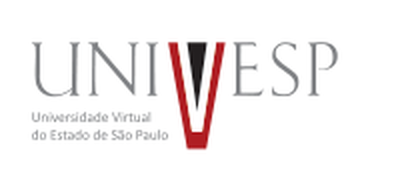
</div>


<div style="
  text-align: center;
  margin-top: 18px;
  margin-bottom: 10px;
">

<h1 style="
  margin-bottom: 8px;
  font-size: 30px;
  line-height: 1.25;
">
  Preparo reprodutível da base Natality 2024
</h1>

<h2 style="
  margin-top: 0;
  margin-bottom: 12px;
  font-size: 20px;
  font-weight: 500;
  color: #374151;
  line-height: 1.35;
">
  Geração auditável do artefato Parquet para uso nos notebooks analíticos do TCC
</h2>

<p style="
  margin-top: 0;
  font-size: 15px;
  color: #4b5563;
">
  <strong>Bacharelado em Ciência de Dados — UNIVESP</strong>
</p>

</div>

<hr style="margin-top: 18px; margin-bottom: 18px;">

<div style="
  background-color: #fff8e1;
  border-left: 6px solid #f0ad4e;
  padding: 14px 18px;
  margin-top: 18px;
  border-radius: 8px;
  line-height: 1.55;
  color: #3f3f46;
">

<strong>⚠️ Aviso metodológico</strong><br>
Este notebook é dedicado exclusivamente ao <strong>preparo reprodutível da base pública Natality Data 2024</strong>. O fluxo inclui aquisição da fonte oficial, extração do arquivo fixed-width, leitura em blocos, limpeza, padronização, engenharia primária de variáveis, validações estruturais, auditoria e gravação do artefato <code>natality_data_2024.parquet</code>.

</div>

<div style="
  background-color: #eef6ff;
  border-left: 6px solid #2196f3;
  padding: 14px 18px;
  margin-top: 14px;
  border-radius: 8px;
  line-height: 1.55;
  color: #334155;
">

<strong>ℹ️ Papel deste notebook no TCC</strong><br>
Este é o <strong>Notebook 01</strong>. Ele não executa regressões, modelos supervisionados nem interpretação estatística final. Sua entrega principal é uma base analítica limpa, validada e rastreável, que será consumida pelo Notebook 02.

</div>


<div style="
  margin: 16px 0 24px 0;
  padding: 14px 18px;
  border: 1px solid #bfdbfe;
  border-left: 6px solid #2563eb;
  border-radius: 6px;
  background: #eff6ff;
  font-size: 13.5px;
  line-height: 1.55;
">

  <strong style="color: #1e40af; font-size: 13px; text-transform: uppercase; letter-spacing: 0.5px;">
    Licença de uso do código e materiais de apoio
  </strong>

  <p style="margin: 8px 0 0 0; color: #374151;">
    Os códigos-fonte, scripts, rotinas de tratamento de dados e materiais técnicos de apoio
    desenvolvidos por <strong>Jalvo Alef Oliveira dos Santos</strong> para este projeto estão
    licenciados sob a licença
    <strong>Creative Commons Atribuição 4.0 Internacional — CC BY 4.0</strong>,
    permitindo uso, compartilhamento, adaptação e reprodução, desde que seja feita a devida
    citação da autoria.
  </p>

  <p style="margin: 10px 0 0 0; color: #4b5563; font-size: 12.5px;">
    <strong>Forma curta:</strong> uso livre mediante citação da autoria.
  </p>

  <p style="margin: 10px 0 0 0; color: #4b5563; font-size: 12.5px;">
    <strong>Citação recomendada do código/material de apoio:</strong><br>
    SANTOS, Jalvo Alef Oliveira dos. <em>Preparo reprodutível da base Natality 2024</em>.
    Códigos-fonte, scripts e apoio metodológico ao Trabalho de Conclusão de Curso —
    UNIVESP. Licença CC BY 4.0. São Paulo, 2026.
  </p>

  <hr style="margin: 14px 0; border: none; border-top: 1px solid #bfdbfe;">

  <p style="margin: 10px 0 0 0; color: #374151; font-size: 12.5px;">
    <strong>Referência do TCC em ABNT:</strong><br>
    SANTOS, Jalvo Alef Oliveira dos; VILELA, Vanessa Soares; RIBEIRO, Julia Beatriz Valentim;
    SORGI, Vanessa Beatriz Mauricio; CALÇADA, David Paulo Francisco; OLIVEIRA, José Paulo da Silva;
    SANTOS, Lucas Gabriel Gallo dos; LIMA, Wagner Santos.
    <strong>Estratificação retrospectiva do risco de internação em UTIN em nascimentos:
    aplicação de Health Analytics à Natality Data 2024, com ênfase em prematuridade e proxy
    operacional compatível com contexto de RPM/PPROM</strong>.
    Relatório Técnico-Científico. Bacharelado em Ciência de Dados — Universidade Virtual do Estado
    de São Paulo. Orientador: Felipe Ivo da Silva. São Paulo, 2026.
  </p>

  <p style="margin: 10px 0 0 0; color: #4b5563; font-size: 12.5px;">
    <strong>Forma curta para citação no texto:</strong><br>
    (SANTOS et al., 2026)
  </p>

  <p style="margin: 10px 0 0 0; color: #4b5563; font-size: 12.5px;">
    <strong>Em frase:</strong><br>
    Santos et al. (2026) analisam a estratificação retrospectiva do risco de internação em UTIN
    com aplicação de Health Analytics à Natality Data 2024.
  </p>

  <p style="margin: 10px 0 0 0; color: #6b7280; font-size: 12px;">
    <strong>Observação:</strong> esta licença se aplica aos códigos-fonte, scripts e materiais
    técnicos de apoio desenvolvidos por Jalvo Alef Oliveira dos Santos. A referência ao TCC é
    apresentada para fins de citação acadêmica da obra coletiva.
  </p>

</div>

<div style="
  background-color: #e8f5e9;
  border-left: 6px solid #2e7d32;
  border-radius: 8px;
  padding: 14px 18px;
  margin-top: 14px;
  text-align: center;
  font-size: 17px;
  font-weight: 600;
  color: #1b5e20;
  line-height: 1.45;
">
  ✅ Pipeline idempotente para preparo da base <strong>Natality 2024.</strong>
</div>


<div style="margin: 0 0 24px 0; padding: 16px 20px; background: #eff6ff; border: 1px solid #bfdbfe; border-radius: 4px;">
  <strong style="color: #1e40af; font-size: 13px;">Objetivo</strong>
  <p style="margin: 6px 0 0 0; color: #374151; font-size: 13.5px; line-height: 1.6;">
    Preparar, documentar e auditar o artefato analítico primário <code>natality_data_2024.parquet</code> a partir dos microdados públicos de natalidade dos Estados Unidos (CDC/NCHS, 2024). O conteúdo foi mantido aderente ao título do notebook: foco em preparo, qualidade, rastreabilidade e reprodutibilidade da base.
  </p>
</div>

### Escopo do processamento

| Etapa | Operação | Artefato de saída |
|:---:|---|---|
| 1 | Aquisição do arquivo público oficial | `data/raw/natality_2024/` |
| 2 | Extração do TXT fixed-width | `Nat2024PublicUS.*.txt` |
| 3 | Leitura em blocos, limpeza e engenharia primária de variáveis | Base tratada em memória |
| 4 | Gravação incremental em Parquet com compressão Snappy | `natality_data_2024.parquet` |
| 5 | Validação estrutural, conferência de schema e auditoria | CSVs auxiliares de validação |
| 6 | Registro final de rastreabilidade para uso no Notebook 02 | Manifesto, hashes e resumo final |

### Fora do escopo deste notebook

Regressões, modelos supervisionados, avaliação de desempenho, gráficos analíticos finais e discussão interpretativa pertencem ao Notebook 02.


## Nota da versão de defesa

Esta versão foi ajustada para ser usada como artefato técnico reprodutível do TCC. As melhorias aplicadas foram:

- redução de redundâncias textuais;
- inclusão de manifesto de ambiente computacional;
- inclusão de testes sintéticos das funções críticas;
- reforço do resumo final com trilha de auditoria, hashes e arquivos gerados.

O notebook permanece focado no **preparo reprodutível da Natality 2024**. Modelagem, interpretação estatística e discussão científica devem continuar nos notebooks e capítulos próprios do TCC.


In [1]:
# Figura 1 — Fluxo reprodutível de preparo da base Natality 2024
# Execute esta célula para renderizar o fluxo técnico em formato visual.
# A saída também foi salva no notebook para visualização imediata em Jupyter/Colab.

from IPython.display import HTML, display

pipeline_html = r"""
<div style="max-width:1180px;margin:18px auto 28px auto;font-family:Arial,Helvetica,sans-serif;">
<svg viewBox="0 0 1180 780" width="100%" role="img" aria-label="Figura 1 — Fluxo reprodutível de preparo da base Natality 2024">
<defs>
<linearGradient id="headerGrad" x1="0%" y1="0%" x2="100%" y2="0%">
<stop offset="0%" style="stop-color:#0f172a"/><stop offset="45%" style="stop-color:#1d4ed8"/><stop offset="100%" style="stop-color:#0284c7"/>
</linearGradient>
<filter id="shadow" x="-10%" y="-10%" width="130%" height="130%"><feDropShadow dx="0" dy="4" stdDeviation="6" flood-color="#0f172a" flood-opacity="0.18"/></filter>
<marker id="arrow" markerWidth="14" markerHeight="14" refX="11" refY="7" orient="auto"><path d="M0,0 L14,7 L0,14 z" fill="#64748b"/></marker>
<style>
.title{font:700 30px Arial,sans-serif;fill:#fff}.subtitle{font:400 15px Arial,sans-serif;fill:#dbeafe}
.card-title{font:700 17px Arial,sans-serif;fill:#0f172a}.card-text{font:400 13px Arial,sans-serif;fill:#334155}
.badge{font:700 12px Arial,sans-serif;fill:#fff}.small-title{font:700 14px Arial,sans-serif;fill:#0f172a}.small-text{font:400 12.5px Arial,sans-serif;fill:#475569}
</style>
</defs>
<rect x="0" y="0" width="1180" height="780" rx="22" fill="#f8fafc"/>
<rect x="24" y="22" width="1132" height="116" rx="18" fill="url(#headerGrad)" filter="url(#shadow)"/>
<text x="54" y="68" class="title">Figura 1 — Fluxo reprodutível de preparo da base Natality 2024</text>
<text x="54" y="96" class="subtitle">Da fonte pública Natality Data 2024 ao artefato Parquet validado e auditável</text>
<text x="54" y="119" class="subtitle">Leitura para a banca: cada etapa gera evidência de rastreabilidade, integridade e reprodutibilidade.</text>

<g filter="url(#shadow)"><rect x="42" y="178" width="235" height="128" rx="18" fill="#fff" stroke="#bfdbfe"/><circle cx="70" cy="205" r="18" fill="#2563eb"/><text x="64" y="210" class="badge">1</text><text x="98" y="203" class="card-title">Ambiente</text><text x="98" y="225" class="card-text">Python, pacotes e diretórios</text><text x="60" y="260" class="card-text">• dependências explícitas</text><text x="60" y="280" class="card-text">• parâmetros centralizados</text></g>
<g filter="url(#shadow)"><rect x="322" y="178" width="235" height="128" rx="18" fill="#fff" stroke="#bae6fd"/><circle cx="350" cy="205" r="18" fill="#0284c7"/><text x="344" y="210" class="badge">2</text><text x="378" y="203" class="card-title">Fonte oficial</text><text x="378" y="225" class="card-text">ZIP/TXT da Natality 2024</text><text x="340" y="260" class="card-text">• localização ou download</text><text x="340" y="280" class="card-text">• hash SHA-256 do insumo</text></g>
<g filter="url(#shadow)"><rect x="602" y="178" width="235" height="128" rx="18" fill="#fff" stroke="#bbf7d0"/><circle cx="630" cy="205" r="18" fill="#16a34a"/><text x="624" y="210" class="badge">3</text><text x="658" y="203" class="card-title">Leitura fixed-width</text><text x="658" y="225" class="card-text">Layout oficial por posição</text><text x="620" y="260" class="card-text">• leitura em chunks</text><text x="620" y="280" class="card-text">• baixo consumo de memória</text></g>
<g filter="url(#shadow)"><rect x="882" y="178" width="235" height="128" rx="18" fill="#fff" stroke="#fed7aa"/><circle cx="910" cy="205" r="18" fill="#f97316"/><text x="904" y="210" class="badge">4</text><text x="938" y="203" class="card-title">Limpeza</text><text x="938" y="225" class="card-text">Códigos especiais e missing</text><text x="900" y="260" class="card-text">• preservação de NaN</text><text x="900" y="280" class="card-text">• exclusão controlada</text></g>
<line x1="284" y1="242" x2="313" y2="242" stroke="#64748b" stroke-width="3" marker-end="url(#arrow)"/>
<line x1="564" y1="242" x2="593" y2="242" stroke="#64748b" stroke-width="3" marker-end="url(#arrow)"/>
<line x1="844" y1="242" x2="873" y2="242" stroke="#64748b" stroke-width="3" marker-end="url(#arrow)"/>
<path d="M1000 314 C1000 355,1000 370,1000 398" fill="none" stroke="#64748b" stroke-width="3" marker-end="url(#arrow)"/>

<g filter="url(#shadow)"><rect x="882" y="412" width="235" height="128" rx="18" fill="#fff" stroke="#ddd6fe"/><circle cx="910" cy="439" r="18" fill="#7c3aed"/><text x="904" y="444" class="badge">5</text><text x="938" y="437" class="card-title">Engenharia</text><text x="938" y="459" class="card-text">Variáveis derivadas</text><text x="900" y="494" class="card-text">• PRETERM, LOW_BW</text><text x="900" y="514" class="card-text">• proxies operacionais</text></g>
<g filter="url(#shadow)"><rect x="602" y="412" width="235" height="128" rx="18" fill="#fff" stroke="#fecdd3"/><circle cx="630" cy="439" r="18" fill="#e11d48"/><text x="624" y="444" class="badge">6</text><text x="658" y="437" class="card-title">Parquet</text><text x="658" y="459" class="card-text">Artefato analítico final</text><text x="620" y="494" class="card-text">• schema estável</text><text x="620" y="514" class="card-text">• compressão e leitura rápida</text></g>
<g filter="url(#shadow)"><rect x="322" y="412" width="235" height="128" rx="18" fill="#fff" stroke="#fde68a"/><circle cx="350" cy="439" r="18" fill="#ca8a04"/><text x="344" y="444" class="badge">7</text><text x="378" y="437" class="card-title">Validações</text><text x="378" y="459" class="card-text">Controles de integridade</text><text x="340" y="494" class="card-text">• linhas, colunas e schema</text><text x="340" y="514" class="card-text">• testes sintéticos</text></g>
<g filter="url(#shadow)"><rect x="42" y="412" width="235" height="128" rx="18" fill="#fff" stroke="#c7d2fe"/><circle cx="70" cy="439" r="18" fill="#4f46e5"/><text x="64" y="444" class="badge">8</text><text x="98" y="437" class="card-title">Auditoria</text><text x="98" y="459" class="card-text">Evidências para defesa</text><text x="60" y="494" class="card-text">• CSVs de rastreabilidade</text><text x="60" y="514" class="card-text">• manifesto e checks finais</text></g>
<line x1="873" y1="476" x2="844" y2="476" stroke="#64748b" stroke-width="3" marker-end="url(#arrow)"/>
<line x1="593" y1="476" x2="564" y2="476" stroke="#64748b" stroke-width="3" marker-end="url(#arrow)"/>
<line x1="313" y1="476" x2="284" y2="476" stroke="#64748b" stroke-width="3" marker-end="url(#arrow)"/>

<rect x="42" y="584" width="1075" height="178" rx="20" fill="#ffffff" stroke="#e2e8f0" filter="url(#shadow)"/>
<text x="66" y="616" class="small-title">Síntese executiva do fluxo</text>
<text x="66" y="639" class="small-text">O bloco abaixo resume, para a banca, o que entra, o que sai e qual evidência metodológica o notebook entrega.</text>

<!-- Cards redesenhados: mais altos, com ícones centralizados e texto sem estouro -->
<g>
  <rect x="66" y="658" width="328" height="82" rx="16" fill="#eff6ff" stroke="#bfdbfe"/>
  <circle cx="94" cy="699" r="17" fill="#2563eb"/>
  <text x="94" y="699" text-anchor="middle" dominant-baseline="middle" class="badge">E</text>
  <text x="124" y="685" class="small-title">Entrada</text>
  <text x="124" y="706" class="small-text">Arquivo fixed-width Natality Data 2024</text>
  <text x="124" y="724" class="small-text">+ layout oficial do NCHS.</text>
</g>

<g>
  <rect x="426" y="658" width="348" height="82" rx="16" fill="#f8fafc" stroke="#cbd5e1"/>
  <circle cx="454" cy="699" r="17" fill="#64748b"/>
  <text x="454" y="699" text-anchor="middle" dominant-baseline="middle" class="badge">S</text>
  <text x="484" y="685" class="small-title">Saída</text>
  <text x="484" y="706" class="small-text">Base analítica em Parquet + CSVs de auditoria,</text>
  <text x="484" y="724" class="small-text">completude, validações, contagens e manifesto.</text>
</g>

<g>
  <rect x="806" y="658" width="286" height="82" rx="16" fill="#ecfdf5" stroke="#86efac"/>
  <circle cx="834" cy="699" r="17" fill="#16a34a"/>
  <text x="834" y="699" text-anchor="middle" dominant-baseline="middle" class="badge">✓</text>
  <text x="864" y="685" class="small-title">Mensagem central</text>
  <text x="864" y="706" class="small-text">O notebook não apenas processa dados:</text>
  <text x="864" y="724" class="small-text">ele documenta, valida e prova o preparo.</text>
</g>
</svg>
</div>
"""

display(HTML(pipeline_html))


> **Fallback textual da Figura 1:** Ambiente → Fonte oficial → Leitura fixed-width → Limpeza → Engenharia de variáveis → Parquet → Validações → Auditoria.  
> Caso o visual não apareça no ambiente usado, execute a célula acima; ela usa `IPython.display.HTML`, mais confiável que HTML solto em Markdown.


## Orientações de execução

<div style="margin: 18px 0; padding: 14px 18px; border-left: 4px solid #d97706; background: #fffbeb; border-radius: 4px; font-size: 13.5px; line-height: 1.6;">
  <strong style="color: #92400e; font-size: 13px; text-transform: uppercase; letter-spacing: 0.5px;">Execução sequencial obrigatória</strong>
  <p style="margin: 6px 0 0 0; color: #374151;">As células deste notebook devem ser executadas na ordem apresentada. A omissão de etapas intermediárias pode resultar em artefatos incompletos ou inconsistentes.</p>
</div>

**Pré-requisitos do ambiente:**

- Python 3.10 ou superior com kernel IPython
- Conexão com internet para download inicial (~700 MB)
- Espaço em disco: mínimo 2 GB livres
- Memória RAM: mínimo 16 GB disponíveis
- Para execução final do TCC: variável de ambiente `NATALITY_TEST_ROWS` não definida



## Artefatos produzidos

<div style="font-size: 13.5px;">

| Arquivo | Formato | Descrição |
|---|:---:|---|
| `natality_data_2024.parquet` | Parquet | Artefato analítico principal (31 variáveis) |
| `auditoria_preparo_natality_2024.csv` | CSV | Metadados de execução e rastreabilidade |
| `missing_pct_natality_2024.csv` | CSV | Completude por variável |
| `checks_preparo_natality_2024.csv` | CSV | Validações de integridade |
| `semantic_value_counts_natality_2024.csv` | CSV | Distribuição final de categorias após limpeza |
| `raw_value_counts_natality_2024.csv` | CSV | Distribuição de códigos brutos antes da limpeza |
| `exclusoes_preparo_natality_2024.csv` | CSV | Critérios e volume de exclusões da amostra analítica |

</div>

<div style="margin: 18px 0; padding: 14px 18px; border-left: 4px solid #3b82f6; background: #eff6ff; border-radius: 4px; font-size: 13.5px; line-height: 1.6;">
  <strong style="color: #1e40af; font-size: 13px; text-transform: uppercase; letter-spacing: 0.5px;">Nota</strong>
  <p style="margin: 6px 0 0 0; color: #374151;">O arquivo <code>natality_prom_nicu_subset_v2.parquet</code> não é mais produzido por este pipeline. Eventuais cópias no diretório são resíduos de versões anteriores.</p>
</div>


## Padrão enxuto de documentação das células

Cada etapa executável deve informar apenas o necessário para auditoria:

1. **Objetivo técnico**: o que a célula faz.
2. **Entrada**: arquivos, parâmetros ou objetos usados.
3. **Saída**: artefato, tabela ou validação produzida.
4. **Decisão metodológica**: regra que pode afetar a interpretação do TCC.

Esta versão evita repetir justificativas gerais em excesso. A prioridade é manter o notebook claro, executável e auditável pela banca.


## Matriz de aderência normativa e padrões aplicáveis

A tabela abaixo registra as normas e boas práticas incorporadas ao notebook. A seleção considera a natureza do artefato: preparação reprodutível de microdados públicos de natalidade, geração de base analítica em Parquet, auditoria de execução, documentação de variáveis e validações de qualidade.

| Referência | Tema | Aplicação prática no notebook |
|---|---|---|
| **ISO/IEC 25012:2008 — Data Quality Model** | Qualidade de dados estruturados | Orienta avaliação de completude, consistência, rastreabilidade, acurácia sintática, conformidade de tipos e documentação de ausências. |
| **ISO 8000 — Data Quality** | Gestão e governança da qualidade de dados | Sustenta a documentação de origem, linhagem, regras de transformação, papéis do artefato e evidências de processamento. |
| **ISO 8601-1 — Date and time format** | Padronização temporal | Recomenda datas em formato `YYYY-MM-DD` e timestamps não ambíguos em auditorias, logs e metadados. |
| **ISO/IEC/IEEE 26512 — Information for users** | Documentação de software e informação para usuários | Fundamenta seções de objetivo, entradas, saídas, limitações, instruções de execução e requisitos de reuso. |
| **ISO/IEC/IEEE 29119 — Software testing** | Testes e validações | Fundamenta checagens de existência de arquivos, contagem de linhas, esquema do Parquet, amostragem e validação pós-processamento. |
| **ISO/IEC/IEEE 12207 — Software life cycle processes** | Processo de ciclo de vida de software | Apoia a organização por etapas: aquisição da fonte, extração, transformação, validação, armazenamento e auditoria. |
| **ISO/IEC 25010 — Software product quality model** | Qualidade de produto de software | Orienta manutenibilidade, confiabilidade, portabilidade e usabilidade do notebook como artefato computacional. |
| **ISO/IEC 27001 e 27002 — Segurança da informação** | Controles e gestão de segurança | Recomenda proteção dos dados, controle de acesso a artefatos, rastreabilidade de fonte e cautela no tratamento de dados de saúde, mesmo quando públicos. |
| **LGPD — Lei nº 13.709/2018** | Proteção de dados pessoais | Reforça finalidade, necessidade, minimização, segurança e cautela ética no uso de dados relacionados à saúde e nascimento. |
| **PEP 8** | Estilo de código Python | Orienta nomes, espaçamento, organização dos imports e legibilidade. |
| **PEP 257** | Docstrings em Python | Orienta documentação de funções com comportamento, parâmetros, retornos, exceções e restrições. |
| **PEP 484** | Type hints em Python | Recomenda anotações de tipo em funções auxiliares e parâmetros críticos. |
| **FAIR Principles** | Dados encontráveis, acessíveis, interoperáveis e reutilizáveis | Orienta metadados, nomenclatura clara, documentação de origem, reuso e preservação de artefatos. |
| **DDI-Codebook / Data Documentation Initiative** | Documentação de microdados e pesquisas | Aderente à documentação de variáveis, origem, metodologia, estrutura física do arquivo e códigos especiais. |
| **Frictionless Data Package** | Especificação de metadados tabulares | Inspira documentação de recursos, campos, tipos, fonte, licença, formato e esquema de dados. |

### Critério de aplicação

As normas foram aplicadas como **boas práticas de engenharia de dados e documentação científica**, com os seguintes focos:

1. **Rastreabilidade:** registro de fonte, URL, caminhos, hashes quando aplicável, artefatos de saída e auditorias.
2. **Reprodutibilidade:** dependências explícitas, parâmetros centralizados, execução sequencial e salvamento de evidências.
3. **Qualidade de dados:** validação de tipos, tratamento de códigos especiais, métricas de ausência e conferência do artefato final.
4. **Documentação técnica:** células com objetivo, entrada, saída, limitações e relação com o TCC.
5. **Segurança e ética:** cautela com dados de saúde, minimização do escopo e preservação apenas dos campos necessários ao objetivo analítico.

> **Nota metodológica:** a presença dessas referências no notebook indica aderência documental e procedimental. Certificação ISO, conformidade legal plena ou auditoria regulatória exigiriam processo institucional próprio, evidências adicionais e avaliação independente.


## Glossário técnico do pipeline

| Termo | Significado no notebook |
|---|---|
| **Artefato analítico** | Arquivo final preparado para análise, neste caso o Parquet. |
| **Fixed-width** | Formato em que cada variável ocupa posições fixas na linha do arquivo TXT. |
| **Chunk** | Bloco de linhas lido por vez para reduzir consumo de memória. |
| **Hash SHA-256** | Assinatura digital usada para verificar a rastreabilidade do arquivo bruto. |
| **Parquet** | Formato colunar eficiente para armazenamento e leitura de dados analíticos. |
| **Missing** | Valor ausente, inválido, desconhecido ou não informado. |
| **Auditoria de execução** | Registro técnico que permite reconstituir como, quando e com quais parâmetros o artefato foi gerado. |


## Aderência normativa

<p style="font-size: 13px; color: #6b7280; margin-bottom: 12px;">
A tabela a seguir documenta a correspondência entre os padrões de código adotados neste notebook e as normas técnicas que os fundamentam.
</p>

| Padrão de código | Norma/Referência | Exemplo |
|---|---|---|
| Funções com docstring NumPy-style | ISO/IEC/IEEE 12207; PEP 257 | `clean_chunk()` |
| Caminhos e parâmetros centralizados | ISO 8000; FAIR Principles | `OUTPUT_PATH` |
| Tratamento de exceção com mensagem orientada | ISO/IEC 25010 | `except PermissionError` |
| Conversão de tipos com preservação de NaN | ISO/IEC 25012 | `pd.to_numeric(..., errors="coerce")` |
| Gravação incremental em formato colunar | FAIR Principles | `pq.ParquetWriter()` |
| Validação pós-processamento | ISO/IEC/IEEE 29119 | `checks_df` |
| Hash SHA-256 de proveniência | ISO 8000; DDI-Codebook | `sha256_file()` |
| Auditoria persistida | ISO 8601-1; FAIR | CSVs de auditoria |



<div style="margin: 36px 0 16px 0; padding: 12px 0; border-bottom: 2px solid #1e3a5f;">
  <span style="font-size: 12px; color: #6b7280; text-transform: uppercase; letter-spacing: 1px;">Etapa 1</span>
  <h3 style="margin: 4px 0 0 0; font-size: 17px; color: #1e3a5f; font-weight: 600;">Instalação de dependências obrigatórias</h3>
</div>


<div style="margin: 14px 0 22px 0; padding: 14px 18px; border: 1px solid #bfdbfe; border-left: 6px solid #2563eb; border-radius: 6px; background: #eff6ff; font-size: 14px; line-height: 1.5;">

  <h3 style="margin: 0 0 10px 0; color: #1e3a8a;">
    ℹ️ Instalação de dependências obrigatórias
  </h3>

  <p style="margin: 0 0 12px 0; color: #1e40af;">
    <strong>Descrição técnica:</strong> Antes de processar os microdados, esta etapa prepara o ambiente computacional.
    Ela evita que o notebook falhe por ausência de bibliotecas essenciais.
    <strong>Pontos de controle:</strong> mensagens de instalação, importação ou erro de pacote ausente.
  </p>

  <table style="border-collapse: collapse; width: 100%; font-size: 13px; margin-top: 10px;">
    <thead>
      <tr style="background-color: #dbeafe; border-bottom: 2px solid #2563eb;">
        <th style="padding: 7px 9px; text-align: left; color: #1e3a8a; width: 28%;">Tópico</th>
        <th style="padding: 7px 9px; text-align: left; color: #1e3a8a;">Descrição</th>
      </tr>
    </thead>
    <tbody>
      <tr style="border-bottom: 1px solid #bfdbfe;">
        <td style="padding: 7px 9px; font-weight: 600; color: #1d4ed8;">O que o código faz</td>
        <td style="padding: 7px 9px; color: #1e40af;">Verifica se as bibliotecas necessárias estão disponíveis e instala dependências ausentes para permitir a execução do pipeline.</td>
      </tr>
      <tr style="border-bottom: 1px solid #bfdbfe;">
        <td style="padding: 7px 9px; font-weight: 600; color: #1d4ed8;">Entradas/insumos</td>
        <td style="padding: 7px 9px; color: #1e40af;">Ambiente Python/Jupyter e lista de pacotes obrigatórios/opcionais.</td>
      </tr>
      <tr style="border-bottom: 1px solid #bfdbfe;">
        <td style="padding: 7px 9px; font-weight: 600; color: #1d4ed8;">Saídas/resultado esperado</td>
        <td style="padding: 7px 9px; color: #1e40af;">Ambiente preparado para executar as próximas etapas; mensagens de diagnóstico em caso de falha.</td>
      </tr>
      <tr>
        <td style="padding: 7px 9px; font-weight: 600; color: #1d4ed8;">Observação para o TCC</td>
        <td style="padding: 7px 9px; color: #1e40af;">Garante reprodutibilidade operacional em ambientes acadêmicos distintos, sem alterar a lógica analítica do estudo.</td>
      </tr>
    </tbody>
  </table>

</div>

In [2]:
# 0. Instalação de dependências obrigatórias no início do notebook
# -------------------------------------------------------------------------
# Padrões aderentes: ISO/IEC/IEEE 12207; ISO/IEC/IEEE 26512; PEP 8.
# Justificativa: dependências explícitas favorecem reprodutibilidade, manutenção e documentação do ambiente.
#
# Objetivo da célula:
# - garantir que o ambiente tenha as bibliotecas mínimas para executar o preparo;
# - tratar dependência opcional de extração Deflate64 sem interromper o pipeline;
# - emitir mensagens de erro orientadas à ação, úteis para reprodutibilidade.
#
# Observação de boa prática:
# Em ambientes controlados, recomenda-se registrar as versões em um arquivo
# requirements.txt ou environment.yml. Esta célula foi mantida para facilitar a
# execução em ambientes acadêmicos variados, como Jupyter local, Colab ou VS Code.

from __future__ import annotations

import importlib
import subprocess
import sys
import textwrap

# Mapa "módulo importável" -> "nome do pacote no pip".
# Manter este dicionário centralizado evita instalações espalhadas pelo notebook.
REQUIRED_PACKAGES = {
    "numpy": "numpy",
    "pandas": "pandas",
    "requests": "requests",
    "pyarrow": "pyarrow",
}

# Dependência opcional: melhora compatibilidade com ZIPs que usam Deflate64.
# Se não estiver disponível, o notebook tenta métodos alternativos de extração.
OPTIONAL_PACKAGES = {
    "zipfile_deflate64": "zipfile-deflate64",
}


def _module_available(module_name: str) -> bool:
    """Verifica se um módulo Python pode ser importado no ambiente atual.

    Parâmetros
    ----------
    module_name:
        Nome do módulo a ser testado, por exemplo ``"pandas"``.

    Retorna
    -------
    bool
        ``True`` quando o módulo está disponível; ``False`` caso contrário.

    Observações
    -----------
    A função é propositalmente pequena e isolada para deixar explícita a
    diferença entre "pacote instalado" e "pacote que precisa ser instalado".
    """
    try:
        importlib.import_module(module_name)
        return True
    except Exception:
        return False


def _pip_install(package_name: str, required: bool = True) -> bool:
    """Instala um pacote via ``pip`` usando o mesmo Python do kernel.

    Parâmetros
    ----------
    package_name:
        Nome do pacote no repositório pip.
    required:
        Define se a falha de instalação deve interromper o notebook.

    Retorna
    -------
    bool
        ``True`` se a instalação foi concluída; ``False`` se era opcional e
        não pôde ser instalada.

    Exceções
    --------
    RuntimeError
        Quando uma dependência obrigatória não pode ser instalada.

    Observações
    -----------
    A mensagem de erro inclui o comando manual de instalação para facilitar
    reprodução por outro integrante do grupo ou pela banca.
    """
    cmd = [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--upgrade",
        "--prefer-binary",
        package_name,
    ]
    print("Dependência ausente. Instalando:", " ".join(cmd))

    try:
        subprocess.check_call(cmd)
        return True
    except subprocess.CalledProcessError as exc:
        if required:
            raise RuntimeError(
                textwrap.dedent(
                    f"""
                    Falha ao instalar dependência obrigatória: {package_name}

                    Execute manualmente no terminal:

                        {sys.executable} -m pip install --upgrade --prefer-binary {package_name}

                    Depois reinicie o kernel e rode o notebook novamente.
                    """
                )
            ) from exc

        print(f"AVISO: dependência opcional não instalada: {package_name}")
        print("O notebook continuará usando fallback de extração.")
        return False


installed_required = []

for module_name, package_name in REQUIRED_PACKAGES.items():
    if _module_available(module_name):
        print(f"ATIVIDADE JÁ REALIZADA: dependência obrigatória já instalada/importável: {module_name}")
        continue

    print(f"Ausente: {module_name} -> pacote {package_name}")
    if _pip_install(package_name, required=True):
        installed_required.append(package_name)

for module_name, package_name in OPTIONAL_PACKAGES.items():
    if _module_available(module_name):
        print(f"ATIVIDADE JÁ REALIZADA: dependência opcional já instalada/importável: {module_name}")
        continue

    print(f"Opcional ausente: {module_name} -> pacote {package_name}")
    _pip_install(package_name, required=False)

if installed_required:
    print("\nDependências obrigatórias foram instaladas.")
    print("Reiniciando o kernel automaticamente...")
    try:
        from IPython import get_ipython

        get_ipython().kernel.do_shutdown(restart=True)
    except Exception:
        print("Não foi possível reiniciar automaticamente. Reinicie o kernel manualmente.")
else:
    print("\nATIVIDADE JÁ REALIZADA: dependências obrigatórias verificadas. Nada obrigatório precisou ser instalado.")


ATIVIDADE JÁ REALIZADA: dependência obrigatória já instalada/importável: numpy
ATIVIDADE JÁ REALIZADA: dependência obrigatória já instalada/importável: pandas
ATIVIDADE JÁ REALIZADA: dependência obrigatória já instalada/importável: requests
ATIVIDADE JÁ REALIZADA: dependência obrigatória já instalada/importável: pyarrow
Opcional ausente: zipfile_deflate64 -> pacote zipfile-deflate64
Dependência ausente. Instalando: C:\Users\jalvo.santos\AppData\Local\miniconda3\python.exe -m pip install --upgrade --prefer-binary zipfile-deflate64
AVISO: dependência opcional não instalada: zipfile-deflate64
O notebook continuará usando fallback de extração.

ATIVIDADE JÁ REALIZADA: dependências obrigatórias verificadas. Nada obrigatório precisou ser instalado.


<div style="margin: 10px 0 20px 0; padding: 12px 16px; border: 1px solid #bbf7d0; border-left: 6px solid #16a34a; border-radius: 6px; background: #f0fdf4; font-size: 13px;">
  <strong style="color: #166534; font-size: 12px; text-transform: uppercase; letter-spacing: 0.5px;">Resultado esperado</strong>
  <table style="margin-top: 8px; border-collapse: collapse; width: 100%;">
    <tr style="border-bottom: 1px solid #dcfce7;">
      <td style="padding: 5px 8px; font-weight: 600; color: #166534; white-space: nowrap; width: 30%;">Resultado principal</td>
      <td style="padding: 5px 8px; color: #14532d;">Ambiente preparado para execução do pipeline.</td>
    </tr>
    <tr style="border-bottom: 1px solid #dcfce7;">
      <td style="padding: 5px 8px; font-weight: 600; color: #166534; white-space: nowrap; width: 30%;">Saída visível/artefato</td>
      <td style="padding: 5px 8px; color: #14532d;">Bibliotecas obrigatórias disponíveis ou mensagem clara informando o pacote ausente.</td>
    </tr>
    <tr style="border-bottom: 1px solid #dcfce7;">
      <td style="padding: 5px 8px; font-weight: 600; color: #166534; white-space: nowrap; width: 30%;">Uso no pipeline do TCC</td>
      <td style="padding: 5px 8px; color: #14532d;">Nenhum artefato analítico é produzido nesta etapa; ela apenas reduz falhas de ambiente.</td>
    </tr>
    <tr style="border-bottom: 1px solid #dcfce7;">
      <td style="padding: 5px 8px; font-weight: 600; color: #166534; white-space: nowrap; width: 30%;">Atenção metodológica</td>
      <td style="padding: 5px 8px; color: #14532d;">Quando houver instalação em tempo de execução, registrar a versão do ambiente usado na defesa/reprodução.</td>
    </tr>
  </table>
</div>

<div style="margin: 36px 0 16px 0; padding: 12px 0; border-bottom: 2px solid #1e3a5f;">
  <span style="font-size: 12px; color: #6b7280; text-transform: uppercase; letter-spacing: 1px;">Etapa 2</span>
  <h3 style="margin: 4px 0 0 0; font-size: 17px; color: #1e3a5f; font-weight: 600;">Imports e configuração geral</h3>
</div>


<div style="margin: 14px 0 22px 0; padding: 14px 18px; border: 1px solid #bfdbfe; border-left: 6px solid #2563eb; border-radius: 6px; background: #eff6ff; font-size: 14px; line-height: 1.5;">

  <h3 style="margin: 0 0 10px 0; color: #1e3a8a;">
    ℹ️ Imports e configuração geral
  </h3>

  <p style="margin: 0 0 12px 0; color: #1e40af;">
    <strong>Descrição técnica:</strong> Esta etapa carrega os módulos que serão usados para baixar, extrair, ler, transformar, validar e gravar os dados.
    <strong>Pontos de controle:</strong> imports bem-sucedidos e variável de suporte a <code style="background: #dbeafe; color: #1e3a8a; padding: 1px 4px; border-radius: 3px;">Deflate64</code> definida.
  </p>

  <table style="border-collapse: collapse; width: 100%; font-size: 13px; margin-top: 10px;">
    <thead>
      <tr style="background-color: #dbeafe; border-bottom: 2px solid #2563eb;">
        <th style="padding: 7px 9px; text-align: left; color: #1e3a8a; width: 28%;">Tópico</th>
        <th style="padding: 7px 9px; text-align: left; color: #1e3a8a;">Descrição</th>
      </tr>
    </thead>
    <tbody>
      <tr style="border-bottom: 1px solid #bfdbfe;">
        <td style="padding: 7px 9px; font-weight: 600; color: #1d4ed8;">O que o código faz</td>
        <td style="padding: 7px 9px; color: #1e40af;">Carrega bibliotecas de sistema, manipulação de dados, leitura Parquet, download e suporte à extração de arquivos compactados.</td>
      </tr>
      <tr style="border-bottom: 1px solid #bfdbfe;">
        <td style="padding: 7px 9px; font-weight: 600; color: #1d4ed8;">Entradas/insumos</td>
        <td style="padding: 7px 9px; color: #1e40af;">Bibliotecas Python instaladas no ambiente de execução.</td>
      </tr>
      <tr style="border-bottom: 1px solid #bfdbfe;">
        <td style="padding: 7px 9px; font-weight: 600; color: #1d4ed8;">Saídas/resultado esperado</td>
        <td style="padding: 7px 9px; color: #1e40af;">Módulos importados e indicação de suporte a arquivos ZIP com <code style="background: #dbeafe; color: #1e3a8a; padding: 1px 4px; border-radius: 3px;">Deflate64</code>.</td>
      </tr>
      <tr>
        <td style="padding: 7px 9px; font-weight: 600; color: #1d4ed8;">Observação para o TCC</td>
        <td style="padding: 7px 9px; color: #1e40af;">Centraliza dependências e torna explícitos os recursos computacionais usados no preparo da base.</td>
      </tr>
    </tbody>
  </table>

</div>

In [3]:
# 1. Imports e configuração geral
# -------------------------------------------------------------------------
# Padrões aderentes: PEP 8; ISO/IEC 25010; ISO/IEC/IEEE 26512.
# Justificativa: imports centralizados aumentam legibilidade, manutenibilidade e rastreabilidade do ambiente.
#
# Objetivo da célula:
# - carregar bibliotecas usadas no pipeline de preparo;
# - registrar se o ambiente suporta extração ZIP com Deflate64;
# - concentrar dependências técnicas antes da definição dos parâmetros.
#
# Entradas/insumos:
# - pacotes Python instalados no ambiente do kernel.
#
# Saídas/resultado esperado:
# - módulos importados e variável HAS_DEFLATE64 definida.
#
# Observação metodológica:
# Falhas nesta etapa indicam problema de ambiente, não inconsistência da base.

from pathlib import Path
from zipfile import ZipFile
import hashlib
import os
import shutil
import subprocess
import sys
import time

import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import requests

try:
    # Se disponível, registra suporte a Deflate64 no zipfile.
    import zipfile_deflate64  # noqa: F401
    HAS_DEFLATE64 = True
except Exception:
    HAS_DEFLATE64 = False

print("Suporte zipfile_deflate64:", HAS_DEFLATE64)

Suporte zipfile_deflate64: False


## Ambiente computacional e manifesto de execução

Esta etapa registra o ambiente do kernel e as versões das bibliotecas centrais. O objetivo é facilitar reexecução futura e reduzir ambiguidade sobre dependências.


In [4]:
# 1.1 Registro do ambiente computacional
# -------------------------------------------------------------------------
# Objetivo:
# - registrar versão do Python, sistema operacional e pacotes centrais;
# - criar um arquivo requirements mínimo para reexecução do pipeline;
# - preparar metadados que serão persistidos junto às auditorias.

import platform

CORE_PACKAGES = {
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "pyarrow": pa.__version__,
    "requests": requests.__version__,
}

environment_df = pd.DataFrame(
    [
        {"item": "python", "versao": sys.version.split()[0]},
        {"item": "platform", "versao": platform.platform()},
        {"item": "executable", "versao": sys.executable},
        {"item": "zipfile_deflate64", "versao": str(HAS_DEFLATE64)},
        *[
            {"item": package, "versao": version}
            for package, version in CORE_PACKAGES.items()
        ],
    ]
)

requirements_min = "\n".join(
    [
        f"numpy=={np.__version__}",
        f"pandas=={pd.__version__}",
        f"pyarrow=={pa.__version__}",
        f"requests=={requests.__version__}",
        "zipfile-deflate64  # opcional; necessário apenas se o ZIP exigir Deflate64",
    ]
)

environment_df


,item,versao
0,python,3.13.5
1,platform,Windows-11-10.0.26200-SP0
2,executable,C:\Users\jalvo.santos\AppData\Local\miniconda3...
3,zipfile_deflate64,False
4,numpy,2.4.4
5,pandas,2.3.3
6,pyarrow,24.0.0
7,requests,2.33.1


<div style="margin: 10px 0 20px 0; padding: 12px 16px; border: 1px solid #bbf7d0; border-left: 6px solid #16a34a; border-radius: 6px; background: #f0fdf4; font-size: 13px;">
  <strong style="color: #166534; font-size: 12px; text-transform: uppercase; letter-spacing: 0.5px;">✅ Resultado esperado</strong>
  <table style="margin-top: 8px; border-collapse: collapse; width: 100%;">
    <tr style="border-bottom: 1px solid #dcfce7;">
      <td style="padding: 5px 8px; font-weight: 600; color: #166534; white-space: nowrap; width: 30%;">Resultado principal</td>
      <td style="padding: 5px 8px; color: #14532d;">Bibliotecas carregadas e suporte opcional a Deflate64 identificado.</td>
    </tr>
    <tr style="border-bottom: 1px solid #dcfce7;">
      <td style="padding: 5px 8px; font-weight: 600; color: #166534; white-space: nowrap; width: 30%;">Saída visível/artefato</td>
      <td style="padding: 5px 8px; color: #14532d;">Imports concluídos sem erro e variável de controle <code style="background: #dcfce7; color: #166534; padding: 1px 4px; border-radius: 3px;">HAS_DEFLATE64</code> definida.</td>
    </tr>
    <tr style="border-bottom: 1px solid #dcfce7;">
      <td style="padding: 5px 8px; font-weight: 600; color: #166534; white-space: nowrap; width: 30%;">Uso no pipeline do TCC</td>
      <td style="padding: 5px 8px; color: #14532d;">O notebook passa a ter acesso aos módulos necessários para download, leitura, transformação e gravação.</td>
    </tr>
    <tr style="border-bottom: 1px solid #dcfce7;">
      <td style="padding: 5px 8px; font-weight: 600; color: #166534; white-space: nowrap; width: 30%;">Atenção metodológica</td>
      <td style="padding: 5px 8px; color: #14532d;">Falhas nesta etapa geralmente indicam dependência ausente, não problema metodológico da pesquisa.</td>
    </tr>
  </table>
</div>

<div style="margin: 36px 0 16px 0; padding: 12px 0; border-bottom: 2px solid #1e3a5f;">
  <span style="font-size: 12px; color: #6b7280; text-transform: uppercase; letter-spacing: 1px;">Etapa 3</span>
  <h3 style="margin: 4px 0 0 0; font-size: 17px; color: #1e3a5f; font-weight: 600;">Caminhos e parâmetros</h3>
</div>


<div style="margin: 14px 0 22px 0; padding: 14px 18px; border: 1px solid #bfdbfe; border-left: 6px solid #2563eb; border-radius: 6px; background: #eff6ff; font-size: 14px; line-height: 1.5;">
  <h3 style="margin: 0 0 10px 0; color: #1e3a8a;">
    ℹ️ Imports e configuração geral
  </h3>

  <p style="margin: 0 0 12px 0; color: #1e40af;">
    <strong>Descrição técnica:</strong> Esta etapa carrega os módulos que serão usados para baixar, extrair, ler, transformar, validar e gravar os dados.
    <strong>Pontos de controle:</strong> imports bem-sucedidos e variável de suporte a <code style="background: #dbeafe; color: #1e3a8a; padding: 1px 4px; border-radius: 3px;">Deflate64</code> definida.
  </p>

  <table style="border-collapse: collapse; width: 100%; font-size: 13px; margin-top: 10px;">
    <thead>
      <tr style="background-color: #dbeafe; border-bottom: 2px solid #2563eb;">
        <th style="padding: 7px 9px; text-align: left; color: #1e3a8a; width: 28%;">Tópico</th>
        <th style="padding: 7px 9px; text-align: left; color: #1e3a8a;">Descrição</th>
      </tr>
    </thead>
    <tbody>
      <tr style="border-bottom: 1px solid #bfdbfe;">
        <td style="padding: 7px 9px; font-weight: 600; color: #1d4ed8;">O que o código faz</td>
        <td style="padding: 7px 9px; color: #1e40af;">Carrega bibliotecas de sistema, manipulação de dados, leitura Parquet, download e suporte à extração de arquivos compactados.</td>
      </tr>
      <tr style="border-bottom: 1px solid #bfdbfe;">
        <td style="padding: 7px 9px; font-weight: 600; color: #1d4ed8;">Entradas/insumos</td>
        <td style="padding: 7px 9px; color: #1e40af;">Bibliotecas Python instaladas no ambiente de execução.</td>
      </tr>
      <tr style="border-bottom: 1px solid #bfdbfe;">
        <td style="padding: 7px 9px; font-weight: 600; color: #1d4ed8;">Saídas/resultado esperado</td>
        <td style="padding: 7px 9px; color: #1e40af;">Módulos importados e indicação de suporte a arquivos ZIP com <code style="background: #dbeafe; color: #1e3a8a; padding: 1px 4px; border-radius: 3px;">Deflate64</code>.</td>
      </tr>
      <tr>
        <td style="padding: 7px 9px; font-weight: 600; color: #1d4ed8;">Observação para o TCC</td>
        <td style="padding: 7px 9px; color: #1e40af;">Centraliza dependências e torna explícitos os recursos computacionais usados no preparo da base.</td>
      </tr>
    </tbody>
  </table>
</div>

In [5]:
# 2. Caminhos e parâmetros
# -------------------------------------------------------------------------
# Padrões aderentes: ISO 8601-1; ISO 8000; FAIR Principles; Frictionless Data Package.
# Justificativa: parâmetros e caminhos centralizados tornam origem, destino e metadados do recurso auditáveis.
#
# Centralizar caminhos e parâmetros facilita auditoria, reprodução e revisão
# pela banca. Alterações nesta célula devem ser registradas quando influenciarem
# resultados analíticos do TCC.
# O notebook original usava:
# DATA_PATH = Path("Nat2024PublicUS.c20250512.r20250708.txt")
# OUTPUT_PATH = Path("natality_prom_nicu_subset_v2.parquet")
#
# Nesta versão refatorada, a saída antiga NÃO é mais gerada.
# O único artefato final produzido é `natality_data_2024.parquet`.

# URL oficial do arquivo público usado como insumo bruto.
SOURCE_URL = "https://ftp.cdc.gov/pub/Health_Statistics/NCHS/Datasets/DVS/natality/Nat2024us.zip"

RAW_DIR = Path("data/raw/natality_2024")
PROCESSED_DIR = Path("data/processed")

RAW_ZIP_PATH = RAW_DIR / "Nat2024us.zip"
OUTPUT_PATH = PROCESSED_DIR / "natality_data_2024.parquet"
TMP_OUTPUT_PATH = PROCESSED_DIR / "natality_data_2024.tmp.parquet"

AUDIT_PATH = PROCESSED_DIR / "auditoria_preparo_natality_2024.csv"
MISSING_PATH = PROCESSED_DIR / "missing_pct_natality_2024.csv"
CHECKS_PATH = PROCESSED_DIR / "checks_preparo_natality_2024.csv"
SEMANTIC_COUNTS_PATH = PROCESSED_DIR / "semantic_value_counts_natality_2024.csv"
RAW_COUNTS_PATH = PROCESSED_DIR / "raw_value_counts_natality_2024.csv"
EXCLUSION_PATH = PROCESSED_DIR / "exclusoes_preparo_natality_2024.csv"
ENVIRONMENT_PATH = PROCESSED_DIR / "ambiente_execucao_natality_2024.csv"
REQUIREMENTS_PATH = PROCESSED_DIR / "requirements_preparo_natality_2024.txt"
MANIFEST_PATH = PROCESSED_DIR / "manifesto_artefatos_natality_2024.csv"

# Tamanho do bloco de leitura. Pode ser reduzido em máquinas com pouca memória.
CHUNKSIZE = 250_000

# Codec de compressão do Parquet. Snappy costuma ter boa compatibilidade.
COMPRESSION = "snappy"

# Use None para processar o arquivo inteiro.
# Para teste rápido, use por exemplo 500_000.
N_ROWS_TEST = None

# Total esperado de registros para o arquivo oficial específico usado neste preparo.
# Atenção: este valor é uma validação de versão, não uma constante universal
# da base Natality. Caso o CDC publique arquivo revisado, conferira o hash da
# fonte e atualize EXPECTED_SOURCE_ROWS de forma documentada.
EXPECTED_SOURCE_ROWS = 3_638_436

# Controle de idempotência.
# Quando True, o pipeline reutiliza artefatos já existentes e evita repetir
# atividades caras, como download, extração e processamento completo.
SKIP_IF_EXISTS = True

# Quando True, força reprocessamento mesmo que o Parquet final exista.
# Use apenas se houver mudança metodológica no pipeline.
FORCE_REPROCESS = False

# Quando True, compara artefatos existentes com o manifesto salvo.
# Isso evita reaproveitar auditorias/CSVs defasados em relação ao Parquet atual.
VALIDATE_EXISTING_ARTIFACTS = True


def item_exists(path: Path, require_non_empty: bool = True) -> bool:
    """Verifica existência de arquivo ou diretório antes de qualquer ação.

    Parâmetros
    ----------
    path:
        Caminho a ser verificado.
    require_non_empty:
        Para arquivos, exige tamanho maior que zero.

    Retorna
    -------
    bool
        ``True`` quando o item existe e atende ao critério de tamanho.
    """
    if not path.exists():
        return False

    if path.is_file() and require_non_empty:
        return path.stat().st_size > 0

    return True


def report_already_done(activity: str, path: Path | None = None) -> None:
    """Exibe aviso padronizado para atividades já realizadas."""
    suffix = f" -> {path}" if path is not None else ""
    print(f"ATIVIDADE JÁ REALIZADA: {activity}{suffix}")


def report_will_do(activity: str, path: Path | None = None) -> None:
    """Exibe aviso padronizado para atividades que serão executadas."""
    suffix = f" -> {path}" if path is not None else ""
    print(f"EXECUTANDO ATIVIDADE: {activity}{suffix}")


def ensure_directory(path: Path) -> Path:
    """Cria diretório apenas se ele ainda não existir."""
    if item_exists(path, require_non_empty=False):
        report_already_done("diretório já existe", path)
        return path

    report_will_do("criando diretório", path)
    path.mkdir(parents=True, exist_ok=False)
    print(f"DIRETÓRIO CRIADO: {path}")
    return path


ensure_directory(RAW_DIR)
ensure_directory(PROCESSED_DIR)

print("RAW_DIR:", RAW_DIR.resolve())
print("PROCESSED_DIR:", PROCESSED_DIR.resolve())
print("OUTPUT_PATH:", OUTPUT_PATH)


ATIVIDADE JÁ REALIZADA: diretório já existe -> data\raw\natality_2024
ATIVIDADE JÁ REALIZADA: diretório já existe -> data\processed
RAW_DIR: C:\Meu\TCC\TCC-Entrega2\entrega_final\data\raw\natality_2024
PROCESSED_DIR: C:\Meu\TCC\TCC-Entrega2\entrega_final\data\processed
OUTPUT_PATH: data\processed\natality_data_2024.parquet


<div style="margin: 10px 0 20px 0; padding: 12px 16px; border: 1px solid #bbf7d0; border-left: 6px solid #16a34a; border-radius: 6px; background: #f0fdf4; font-size: 13px;">
  <strong style="color: #166534; font-size: 12px; text-transform: uppercase; letter-spacing: 0.5px;">✅ Resultado esperado</strong>
  <table style="margin-top: 8px; border-collapse: collapse; width: 100%;">
    <tr style="border-bottom: 1px solid #dcfce7;">
      <td style="padding: 5px 8px; font-weight: 600; color: #166534; white-space: nowrap; width: 30%;">Resultado principal</td>
      <td style="padding: 5px 8px; color: #14532d;">Caminhos, parâmetros e nomes dos artefatos definidos de forma centralizada.</td>
    </tr>
    <tr style="border-bottom: 1px solid #dcfce7;">
      <td style="padding: 5px 8px; font-weight: 600; color: #166534; white-space: nowrap; width: 30%;">Saída visível/artefato</td>
      <td style="padding: 5px 8px; color: #14532d;"><code style="background: #dcfce7; color: #166534; padding: 1px 4px; border-radius: 3px;">SOURCE_URL</code>, <code style="background: #dcfce7; color: #166534; padding: 1px 4px; border-radius: 3px;">ZIP_PATH</code>, <code style="background: #dcfce7; color: #166534; padding: 1px 4px; border-radius: 3px;">DATA_PATH</code>, <code style="background: #dcfce7; color: #166534; padding: 1px 4px; border-radius: 3px;">ACTUAL_OUTPUT_PATH</code>, <code style="background: #dcfce7; color: #166534; padding: 1px 4px; border-radius: 3px;">CHUNKSIZE</code>, <code style="background: #dcfce7; color: #166534; padding: 1px 4px; border-radius: 3px;">N_ROWS_TEST</code> e caminhos de auditoria configurados.</td>
    </tr>
    <tr style="border-bottom: 1px solid #dcfce7;">
      <td style="padding: 5px 8px; font-weight: 600; color: #166534; white-space: nowrap; width: 30%;">Uso no pipeline do TCC</td>
      <td style="padding: 5px 8px; color: #14532d;">As próximas células usam esses parâmetros como fonte única de configuração.</td>
    </tr>
    <tr style="border-bottom: 1px solid #dcfce7;">
      <td style="padding: 5px 8px; font-weight: 600; color: #166534; white-space: nowrap; width: 30%;">Atenção metodológica</td>
      <td style="padding: 5px 8px; color: #14532d;"><code style="background: #dcfce7; color: #166534; padding: 1px 4px; border-radius: 3px;">N_ROWS_TEST = None</code> representa execução completa; valores numéricos devem ser tratados como execução de teste.</td>
    </tr>
  </table>
</div>

## Parâmetros de execução e controle de reprodutibilidade

Os parâmetros abaixo concentram decisões que podem alterar o artefato final. Para a versão definitiva do TCC, recomenda-se manter:

- `N_ROWS_TEST = None`, para processar todos os registros;
- `EXPECTED_SOURCE_ROWS = 3_638_436`, correspondente ao total de nascimentos dos Estados Unidos no arquivo público de 2024;
- `COMPRESSION = "snappy"`, por equilíbrio entre desempenho e compatibilidade;
- `CHUNKSIZE = 250_000`, ajustável conforme memória disponível.

Durante testes locais, `N_ROWS_TEST` pode receber um valor menor. Porém, qualquer resultado analítico do TCC deve ser gerado com a base completa.

<div style="margin: 36px 0 16px 0; padding: 12px 0; border-bottom: 2px solid #1e3a5f;">
  <span style="font-size: 12px; color: #6b7280; text-transform: uppercase; letter-spacing: 1px;">Etapa 4</span>
  <h3 style="margin: 4px 0 0 0; font-size: 17px; color: #1e3a5f; font-weight: 600;">Download/localização da fonte</h3>
</div>


<div style="margin: 14px 0 22px 0; padding: 14px 18px; border: 1px solid #bfdbfe; border-left: 6px solid #2563eb; border-radius: 6px; background: #eff6ff; font-size: 14px; line-height: 1.5;">
  <h3 style="margin: 0 0 10px 0; color: #1e3a8a;">
    ℹ️ Download/localização da fonte
  </h3>

  <p style="margin: 0 0 12px 0; color: #1e40af;">
    <strong>Descrição técnica:</strong> Esta etapa garante que a fonte pública oficial exista no computador e registra um hash para comprovar qual arquivo foi usado.
    <strong>Pontos de controle:</strong> caminho do ZIP, tamanho do arquivo e hash <code style="background: #dbeafe; color: #1e3a8a; padding: 1px 4px; border-radius: 3px;">SHA-256</code>.
  </p>

  <table style="border-collapse: collapse; width: 100%; font-size: 13px; margin-top: 10px;">
    <thead>
      <tr style="background-color: #dbeafe; border-bottom: 2px solid #2563eb;">
        <th style="padding: 7px 9px; text-align: left; color: #1e3a8a; width: 28%;">Tópico</th>
        <th style="padding: 7px 9px; text-align: left; color: #1e3a8a;">Descrição</th>
      </tr>
    </thead>
    <tbody>
      <tr style="border-bottom: 1px solid #bfdbfe;">
        <td style="padding: 7px 9px; font-weight: 600; color: #1d4ed8;">O que o código faz</td>
        <td style="padding: 7px 9px; color: #1e40af;">Baixa o arquivo oficial quando necessário, reaproveita cópia local existente e calcula hash SHA-256 do insumo bruto.</td>
      </tr>
      <tr style="border-bottom: 1px solid #bfdbfe;">
        <td style="padding: 7px 9px; font-weight: 600; color: #1d4ed8;">Entradas/insumos</td>
        <td style="padding: 7px 9px; color: #1e40af;">URL oficial do arquivo ZIP e diretório local de dados brutos.</td>
      </tr>
      <tr style="border-bottom: 1px solid #bfdbfe;">
        <td style="padding: 7px 9px; font-weight: 600; color: #1d4ed8;">Saídas/resultado esperado</td>
        <td style="padding: 7px 9px; color: #1e40af;">Arquivo ZIP disponível localmente e hash registrado para rastreabilidade.</td>
      </tr>
      <tr>
        <td style="padding: 7px 9px; font-weight: 600; color: #1d4ed8;">Observação para o TCC</td>
        <td style="padding: 7px 9px; color: #1e40af;">Documenta a origem dos dados secundários e permite comprovar que o artefato foi gerado a partir da fonte esperada.</td>
      </tr>
    </tbody>
  </table>
</div>

In [6]:
# 3. Download/localização da fonte
# -------------------------------------------------------------------------
# Padrões aderentes: ISO 8000; FAIR Principles; DDI-Codebook.
# Justificativa: aquisição da fonte oficial deve preservar proveniência, acesso e rastreabilidade do dado.
#
# Objetivo da célula:
# - obter o ZIP oficial da Natality 2024 quando ele ainda não existe localmente;
# - evitar novo download quando o arquivo já está presente;
# - registrar hash SHA-256 para rastreabilidade do insumo bruto.
#
# Boa prática aplicada:
# A função de download é idempotente: rodar a célula novamente não baixa o
# arquivo de novo se ele já estiver íntegro e com tamanho maior que zero.

def download_file(url: str, destination: Path, chunk_size: int = 1024 * 1024) -> Path:
    """Baixa um arquivo em streaming, reutilizando cópia local quando disponível.

    Parâmetros
    ----------
    url:
        Endereço remoto do arquivo bruto.
    destination:
        Caminho local onde o arquivo será salvo.
    chunk_size:
        Tamanho dos blocos de download em bytes. O padrão de 1 MB equilibra
        desempenho e uso de memória.

    Retorna
    -------
    pathlib.Path
        Caminho local do arquivo disponível para as próximas etapas.

    Exceções
    --------
    requests.HTTPError
        Quando o servidor retorna erro HTTP.
    requests.RequestException
        Para falhas de rede, tempo limite ou conexão.
    OSError
        Para falhas de escrita no diretório local.

    Observações
    -----------
    O download em streaming evita carregar todo o ZIP em memória. Isso é
    importante porque a base pública de natalidade é grande.
    """
    ensure_directory(destination.parent)

    if item_exists(destination, require_non_empty=True):
        size_mb = destination.stat().st_size / 1024**2
        report_already_done(f"download já realizado; arquivo local disponível ({size_mb:.1f} MB)", destination)
        return destination

    report_will_do("baixando arquivo oficial", destination)
    print("URL:", url)
    with requests.get(url, stream=True, timeout=60) as response:
        response.raise_for_status()
        total = int(response.headers.get("content-length", 0))
        downloaded = 0

        with destination.open("wb") as file_obj:
            for chunk in response.iter_content(chunk_size=chunk_size):
                if not chunk:
                    continue

                file_obj.write(chunk)
                downloaded += len(chunk)

                if total:
                    pct = downloaded / total * 100
                    print(f"\rProgresso: {pct:5.1f}%", end="")

    print(f"\nDOWNLOAD CONCLUÍDO: {destination}")
    return destination


def sha256_file(path: Path, chunk_size: int = 1024 * 1024) -> str:
    """Calcula o hash SHA-256 de um arquivo local.

    Parâmetros
    ----------
    path:
        Arquivo que será lido em modo binário.
    chunk_size:
        Tamanho dos blocos de leitura em bytes.

    Retorna
    -------
    str
        Hash SHA-256 em formato hexadecimal.

    Observações
    -----------
    O hash não valida a origem por si só, mas permite registrar se o insumo
    bruto usado em uma execução é o mesmo usado em outra execução.
    """
    digest = hashlib.sha256()

    with path.open("rb") as file_obj:
        for chunk in iter(lambda: file_obj.read(chunk_size), b""):
            digest.update(chunk)

    return digest.hexdigest()


zip_path = download_file(SOURCE_URL, RAW_ZIP_PATH)

if item_exists(zip_path, require_non_empty=True):
    print("SHA-256 do ZIP:", sha256_file(zip_path))
else:
    raise FileNotFoundError(f"ZIP esperado não encontrado após a etapa de download: {zip_path}")


ATIVIDADE JÁ REALIZADA: diretório já existe -> data\raw\natality_2024
ATIVIDADE JÁ REALIZADA: download já realizado; arquivo local disponível (221.1 MB) -> data\raw\natality_2024\Nat2024us.zip
SHA-256 do ZIP: 8ce1c61bc055b3327311985f918db5387ea6a1ed7d34b367afe30f468b92225a


<div style="margin: 10px 0 20px 0; padding: 12px 16px; border: 1px solid #bbf7d0; border-left: 6px solid #16a34a; border-radius: 6px; background: #f0fdf4; font-size: 13px;">
  <strong style="color: #166534; font-size: 12px; text-transform: uppercase; letter-spacing: 0.5px;">✅ Resultado esperado</strong>
  <table style="margin-top: 8px; border-collapse: collapse; width: 100%;">
    <tr style="border-bottom: 1px solid #dcfce7;">
      <td style="padding: 5px 8px; font-weight: 600; color: #166534; white-space: nowrap; width: 30%;">Resultado principal</td>
      <td style="padding: 5px 8px; color: #14532d;">Arquivo ZIP oficial localizado localmente ou baixado da fonte configurada.</td>
    </tr>
    <tr style="border-bottom: 1px solid #dcfce7;">
      <td style="padding: 5px 8px; font-weight: 600; color: #166534; white-space: nowrap; width: 30%;">Saída visível/artefato</td>
      <td style="padding: 5px 8px; color: #14532d;">Exibição do caminho do ZIP, tamanho em bytes e hash <code style="background: #dcfce7; color: #166534; padding: 1px 4px; border-radius: 3px;">SHA-256</code>.</td>
    </tr>
    <tr style="border-bottom: 1px solid #dcfce7;">
      <td style="padding: 5px 8px; font-weight: 600; color: #166534; white-space: nowrap; width: 30%;">Uso no pipeline do TCC</td>
      <td style="padding: 5px 8px; color: #14532d;">O hash permite registrar a rastreabilidade do insumo bruto usado na geração do Parquet.</td>
    </tr>
    <tr style="border-bottom: 1px solid #dcfce7;">
      <td style="padding: 5px 8px; font-weight: 600; color: #166534; white-space: nowrap; width: 30%;">Atenção metodológica</td>
      <td style="padding: 5px 8px; color: #14532d;">Caso o download falhe, verificar rede, URL oficial e permissão de escrita no diretório.</td>
    </tr>
  </table>
</div>

<div style="margin: 36px 0 16px 0; padding: 12px 0; border-bottom: 2px solid #1e3a5f;">
  <span style="font-size: 12px; color: #6b7280; text-transform: uppercase; letter-spacing: 1px;">Etapa 5</span>
  <h3 style="margin: 4px 0 0 0; font-size: 17px; color: #1e3a5f; font-weight: 600;">Localizar ou extrair o TXT</h3>
</div>


<div style="margin: 14px 0 22px 0; padding: 14px 18px; border: 1px solid #bfdbfe; border-left: 6px solid #2563eb; border-radius: 6px; background: #eff6ff; font-size: 14px; line-height: 1.5;">
  <h3 style="margin: 0 0 10px 0; color: #1e3a8a;">
    ℹ️ Localizar ou extrair o TXT
  </h3>

  <p style="margin: 0 0 12px 0; color: #1e40af;">
    <strong>Descrição técnica:</strong> O dado vem compactado. Esta etapa transforma o insumo ZIP em um TXT utilizável pelo pandas.
    <strong>Pontos de controle:</strong> mensagens de extração, caminhos encontrados e possíveis limitações de <code style="background: #dbeafe; color: #1e3a8a; padding: 1px 4px; border-radius: 3px;">Deflate64</code>.
  </p>

  <table style="border-collapse: collapse; width: 100%; font-size: 13px; margin-top: 10px;">
    <thead>
      <tr style="background-color: #dbeafe; border-bottom: 2px solid #2563eb;">
        <th style="padding: 7px 9px; text-align: left; color: #1e3a8a; width: 28%;">Tópico</th>
        <th style="padding: 7px 9px; text-align: left; color: #1e3a8a;">Descrição</th>
      </tr>
    </thead>
    <tbody>
      <tr style="border-bottom: 1px solid #bfdbfe;">
        <td style="padding: 7px 9px; font-weight: 600; color: #1d4ed8;">O que o código faz</td>
        <td style="padding: 7px 9px; color: #1e40af;">Localiza o arquivo TXT já extraído ou extrai o conteúdo do ZIP, incluindo alternativas para ambientes com limitação de Deflate64.</td>
      </tr>
      <tr style="border-bottom: 1px solid #bfdbfe;">
        <td style="padding: 7px 9px; font-weight: 600; color: #1d4ed8;">Entradas/insumos</td>
        <td style="padding: 7px 9px; color: #1e40af;">ZIP oficial baixado e diretório de dados brutos.</td>
      </tr>
      <tr style="border-bottom: 1px solid #bfdbfe;">
        <td style="padding: 7px 9px; font-weight: 600; color: #1d4ed8;">Saídas/resultado esperado</td>
        <td style="padding: 7px 9px; color: #1e40af;">Caminho do arquivo TXT fixed-width usado como insumo principal do processamento.</td>
      </tr>
      <tr>
        <td style="padding: 7px 9px; font-weight: 600; color: #1d4ed8;">Observação para o TCC</td>
        <td style="padding: 7px 9px; color: #1e40af;">Reduz falhas de reprodução e registra claramente a transição do arquivo compactado para o arquivo bruto analisável.</td>
      </tr>
    </tbody>
  </table>
</div>

In [7]:
# 4. Localizar ou extrair o TXT
# -------------------------------------------------------------------------
# Padrões aderentes: ISO/IEC/IEEE 12207; ISO 8000; ISO/IEC 25012.
# Justificativa: extração controlada e seleção do arquivo físico reduzem ambiguidade e favorecem repetibilidade.
#
# Objetivo da célula:
# - localizar um TXT já extraído, quando existir;
# - tentar extração automática do ZIP oficial;
# - usar fallbacks compatíveis com Windows quando o ZIP usar Deflate64;
# - orientar extração manual apenas quando todas as alternativas falharem.
#
# Boa prática aplicada:
# Cada função abaixo faz uma única tarefa. Isso facilita teste, manutenção e
# leitura por avaliadores que queiram entender a etapa de obtenção do arquivo.

def find_existing_txt(raw_dir: Path) -> Path | None:
    """Localiza um arquivo TXT dentro do diretório bruto.

    Parâmetros
    ----------
    raw_dir:
        Diretório onde o ZIP oficial e/ou o TXT extraído devem estar salvos.

    Retorna
    -------
    pathlib.Path | None
        Caminho do TXT encontrado. Retorna ``None`` quando nenhum arquivo
        compatível é localizado.

    Observações
    -----------
    A busca prioriza nomes que contenham ``nat2024`` ou ``natality`` para
    reduzir a chance de selecionar um TXT não relacionado ao projeto.
    """
    candidates = sorted(
        list(raw_dir.glob("*.txt"))
        + list(raw_dir.glob("*.TXT"))
        + list(raw_dir.glob("**/*.txt"))
        + list(raw_dir.glob("**/*.TXT"))
    )
    candidates = [path for path in candidates if path.is_file()]

    if not candidates:
        return None

    preferred = [
        path
        for path in candidates
        if "nat2024" in path.name.lower() or "natality" in path.name.lower()
    ]

    return preferred[0] if preferred else candidates[0]


def inspect_zip_members(zip_path: Path) -> list:
    """Lista membros do ZIP e informa métodos de compressão encontrados.

    Parâmetros
    ----------
    zip_path:
        Caminho do arquivo ZIP oficial.

    Retorna
    -------
    list
        Lista de objetos ``ZipInfo`` referentes aos arquivos internos do ZIP.

    Observações
    -----------
    A inspeção auxilia no diagnóstico de falhas de extração, especialmente
    quando o método de compressão não é suportado pelo ``zipfile`` padrão.
    """
    with ZipFile(zip_path) as zip_file:
        members = zip_file.infolist()
        methods = sorted({member.compress_type for member in members})

    print("Métodos de compressão encontrados no ZIP:", methods)
    print("Primeiros membros:", [member.filename for member in members[:5]])

    return members


def find_7z() -> str | None:
    """Procura o executável 7-Zip no PATH e em locais comuns do Windows.

    Retorna
    -------
    str | None
        Caminho do executável encontrado ou ``None`` quando indisponível.
    """
    candidates = [
        shutil.which("7z"),
        shutil.which("7za"),
        r"C:\Program Files\7-Zip\7z.exe",
        r"C:\Program Files (x86)\7-Zip\7z.exe",
    ]

    for candidate in candidates:
        if candidate and Path(candidate).exists():
            return str(candidate)

    return None


def find_winrar() -> str | None:
    """Procura WinRAR/UnRAR no PATH e em locais comuns do Windows.

    Retorna
    -------
    str | None
        Caminho do executável encontrado ou ``None`` quando indisponível.
    """
    candidates = [
        shutil.which("WinRAR"),
        shutil.which("UnRAR"),
        r"C:\Program Files\WinRAR\WinRAR.exe",
        r"C:\Program Files\WinRAR\UnRAR.exe",
        r"C:\Program Files (x86)\WinRAR\WinRAR.exe",
        r"C:\Program Files (x86)\WinRAR\UnRAR.exe",
    ]

    for candidate in candidates:
        if candidate and Path(candidate).exists():
            return str(candidate)

    return None


def extract_with_7z(zip_path: Path, output_dir: Path) -> bool:
    """Tenta extrair o ZIP usando 7-Zip.

    Parâmetros
    ----------
    zip_path:
        Arquivo ZIP a ser extraído.
    output_dir:
        Diretório de destino da extração.

    Retorna
    -------
    bool
        ``True`` se a extração foi concluída; ``False`` caso contrário.
    """
    executable = find_7z()

    if not executable:
        return False

    report_will_do(f"extraindo ZIP com 7-Zip ({executable})", output_dir)
    command = [executable, "x", str(zip_path), f"-o{output_dir}", "-y"]
    completed = subprocess.run(command, text=True, capture_output=True)

    if completed.returncode != 0:
        print("7-Zip falhou.")
        print(completed.stdout[-1000:])
        print(completed.stderr[-1000:])
        return False

    return True


def extract_with_winrar(zip_path: Path, output_dir: Path) -> bool:
    """Tenta extrair o ZIP usando WinRAR ou UnRAR.

    Parâmetros
    ----------
    zip_path:
        Arquivo ZIP a ser extraído.
    output_dir:
        Diretório de destino da extração.

    Retorna
    -------
    bool
        ``True`` se a extração foi concluída; ``False`` caso contrário.
    """
    executable = find_winrar()

    if not executable:
        return False

    report_will_do(f"extraindo ZIP com WinRAR/UnRAR ({executable})", output_dir)
    command = [executable, "x", "-y", str(zip_path), str(output_dir)]
    completed = subprocess.run(command, text=True, capture_output=True)

    if completed.returncode != 0:
        print("WinRAR/UnRAR falhou.")
        print(completed.stdout[-1000:])
        print(completed.stderr[-1000:])
        return False

    return True


def locate_or_extract_txt(raw_dir: Path, zip_path: Path) -> Path:
    """Localiza ou extrai o arquivo TXT usado na leitura fixed-width.

    Parâmetros
    ----------
    raw_dir:
        Diretório local dos arquivos brutos.
    zip_path:
        Caminho esperado do ZIP oficial.

    Retorna
    -------
    pathlib.Path
        Caminho do TXT que será processado.

    Exceções
    --------
    FileNotFoundError
        Quando nem o TXT nem o ZIP são encontrados, ou quando o ZIP não contém
        arquivo TXT.
    RuntimeError
        Quando as tentativas automáticas de extração falham.

    Observações
    -----------
    A função separa claramente as estratégias de extração para manter o fluxo
    reprodutível em diferentes sistemas operacionais.
    """
    existing = find_existing_txt(raw_dir)

    if existing:
        size_mb = existing.stat().st_size / 1024**2
        report_already_done(f"extração/localização do TXT; arquivo disponível ({size_mb:.1f} MB)", existing)
        return existing

    if not zip_path.exists():
        raise FileNotFoundError(
            f"Não encontrei TXT nem ZIP em {raw_dir}. "
            f"Baixe {SOURCE_URL} ou coloque o TXT extraído nessa pasta."
        )

    members = inspect_zip_members(zip_path)
    txt_members = [member for member in members if member.filename.lower().endswith(".txt")]

    if not txt_members:
        raise FileNotFoundError("Nenhum arquivo .txt encontrado dentro do ZIP.")

    try:
        with ZipFile(zip_path) as zip_file:
            member = txt_members[0]
            report_will_do("extraindo TXT com Python", raw_dir / member.filename)
            zip_file.extract(member, raw_dir)

        extracted = find_existing_txt(raw_dir)

        if extracted:
            print("TXT EXTRAÍDO COM PYTHON:", extracted)
            return extracted

    except NotImplementedError:
        print("Python não suporta este método de compressão do ZIP.")
    except Exception as exc:
        print("Falha ao extrair com Python:", repr(exc))

    if extract_with_7z(zip_path, raw_dir):
        extracted = find_existing_txt(raw_dir)
        if extracted:
            print("TXT extraído com 7-Zip:", extracted)
            return extracted

    if extract_with_winrar(zip_path, raw_dir):
        extracted = find_existing_txt(raw_dir)
        if extracted:
            print("TXT extraído com WinRAR/UnRAR:", extracted)
            return extracted

    raise RuntimeError(
        "Não foi possível extrair automaticamente o TXT.\n\n"
        "Solução manual:\n"
        "1. Abra data/raw/natality_2024/Nat2024us.zip com 7-Zip ou WinRAR.\n"
        "2. Extraia o arquivo .txt para data/raw/natality_2024/.\n"
        "3. Rode novamente o notebook.\n\n"
        "Após isso, o notebook detectará o TXT e gerará o Parquet."
    )


DATA_TXT_PATH = locate_or_extract_txt(RAW_DIR, RAW_ZIP_PATH)

if item_exists(DATA_TXT_PATH, require_non_empty=True):
    report_already_done("insumo TXT pronto para processamento", DATA_TXT_PATH)
else:
    raise FileNotFoundError(f"TXT esperado não encontrado ou vazio: {DATA_TXT_PATH}")

print("Arquivo TXT que será usado:", DATA_TXT_PATH)
print("Tamanho do TXT em MB:", round(DATA_TXT_PATH.stat().st_size / 1024**2, 2))


ATIVIDADE JÁ REALIZADA: extração/localização do TXT; arquivo disponível (4673.9 MB) -> data\raw\natality_2024\Nat2024PublicUS.c20250512.r20250708.txt
ATIVIDADE JÁ REALIZADA: insumo TXT pronto para processamento -> data\raw\natality_2024\Nat2024PublicUS.c20250512.r20250708.txt
Arquivo TXT que será usado: data\raw\natality_2024\Nat2024PublicUS.c20250512.r20250708.txt
Tamanho do TXT em MB: 4673.93


<div style="margin: 10px 0 20px 0; padding: 12px 16px; border: 1px solid #bbf7d0; border-left: 6px solid #16a34a; border-radius: 6px; background: #f0fdf4; font-size: 13px;">
  <strong style="color: #166534; font-size: 12px; text-transform: uppercase; letter-spacing: 0.5px;">✅ Resultado esperado</strong>
  <table style="margin-top: 8px; border-collapse: collapse; width: 100%;">
    <tr style="border-bottom: 1px solid #dcfce7;">
      <td style="padding: 5px 8px; font-weight: 600; color: #166534; white-space: nowrap; width: 30%;">Resultado principal</td>
      <td style="padding: 5px 8px; color: #14532d;">Arquivo TXT da Natality 2024 localizado ou extraído do ZIP.</td>
    </tr>
    <tr style="border-bottom: 1px solid #dcfce7;">
      <td style="padding: 5px 8px; font-weight: 600; color: #166534; white-space: nowrap; width: 30%;">Saída visível/artefato</td>
      <td style="padding: 5px 8px; color: #14532d;">Exibição do caminho do TXT e do tamanho do arquivo em bytes.</td>
    </tr>
    <tr style="border-bottom: 1px solid #dcfce7;">
      <td style="padding: 5px 8px; font-weight: 600; color: #166534; white-space: nowrap; width: 30%;">Uso no pipeline do TCC</td>
      <td style="padding: 5px 8px; color: #14532d;">A base bruta em formato fixed-width fica disponível para leitura em blocos.</td>
    </tr>
    <tr style="border-bottom: 1px solid #dcfce7;">
      <td style="padding: 5px 8px; font-weight: 600; color: #166534; white-space: nowrap; width: 30%;">Atenção metodológica</td>
      <td style="padding: 5px 8px; color: #14532d;">Se o ZIP usar <code style="background: #dcfce7; color: #166534; padding: 1px 4px; border-radius: 3px;">Deflate64</code> e o ambiente não suportar a extração, a célula orienta alternativas seguras.</td>
    </tr>
  </table>
</div>

## Layout fixed-width e rastreabilidade das variáveis

O arquivo público de natalidade é distribuído em formato de largura fixa. Por isso, cada variável precisa ser lida a partir de posições específicas do layout oficial.

Neste notebook, `COLSPECS` usa a convenção do `pandas.read_fwf`: início baseado em zero e fim exclusivo. Os comentários ao lado de cada variável mantêm a posição equivalente informada no layout do arquivo para facilitar conferência e auditoria.

As variáveis foram selecionadas por sua relação com os eixos do TCC:

- características maternas e de pré-natal;
- fatores obstétricos e de trabalho de parto;
- idade gestacional, peso ao nascer e pluralidade;
- condições neonatais e internação em UTIN;
- construção de variáveis derivadas para análise exploratória e modelagem.

<div style="margin: 36px 0 16px 0; padding: 12px 0; border-bottom: 2px solid #1e3a5f;">
  <span style="font-size: 12px; color: #6b7280; text-transform: uppercase; letter-spacing: 1px;">Etapa 6</span>
  <h3 style="margin: 4px 0 0 0; font-size: 17px; color: #1e3a5f; font-weight: 600;">Layout fixed-width e listas de variáveis</h3>
</div>


<div style="margin: 14px 0 22px 0; padding: 14px 18px; border: 1px solid #bfdbfe; border-left: 6px solid #2563eb; border-radius: 6px; background: #eff6ff; font-size: 14px; line-height: 1.5;">
  <h3 style="margin: 0 0 10px 0; color: #1e3a8a;">
    ℹ️ Layout fixed-width e listas de variáveis
  </h3>

  <p style="margin: 0 0 12px 0; color: #1e40af;">
    <strong>Descrição técnica:</strong> Como o arquivo é de largura fixa, cada variável precisa ser lida por posição.
    Esta etapa funciona como o dicionário técnico do recorte analítico.
    <strong>Pontos de controle:</strong> <code style="background: #dbeafe; color: #1e3a8a; padding: 1px 4px; border-radius: 3px;">COLSPECS</code>, nomes de colunas, variáveis finais, variáveis derivadas e códigos especiais.
  </p>

  <table style="border-collapse: collapse; width: 100%; font-size: 13px; margin-top: 10px;">
    <thead>
      <tr style="background-color: #dbeafe; border-bottom: 2px solid #2563eb;">
        <th style="padding: 7px 9px; text-align: left; color: #1e3a8a; width: 28%;">Tópico</th>
        <th style="padding: 7px 9px; text-align: left; color: #1e3a8a;">Descrição</th>
      </tr>
    </thead>
    <tbody>
      <tr style="border-bottom: 1px solid #bfdbfe;">
        <td style="padding: 7px 9px; font-weight: 600; color: #1d4ed8;">O que o código faz</td>
        <td style="padding: 7px 9px; color: #1e40af;">Declara posições oficiais das variáveis no arquivo fixed-width e organiza listas de colunas por função analítica.</td>
      </tr>
      <tr style="border-bottom: 1px solid #bfdbfe;">
        <td style="padding: 7px 9px; font-weight: 600; color: #1d4ed8;">Entradas/insumos</td>
        <td style="padding: 7px 9px; color: #1e40af;">Documentação técnica da Natality 2024 e variáveis selecionadas para o TCC.</td>
      </tr>
      <tr style="border-bottom: 1px solid #bfdbfe;">
        <td style="padding: 7px 9px; font-weight: 600; color: #1d4ed8;">Saídas/resultado esperado</td>
        <td style="padding: 7px 9px; color: #1e40af;">Dicionários de layout, listas de colunas finais e grupos de variáveis observadas/derivadas.</td>
      </tr>
      <tr>
        <td style="padding: 7px 9px; font-weight: 600; color: #1d4ed8;">Observação para o TCC</td>
        <td style="padding: 7px 9px; color: #1e40af;">Mantém rastreabilidade entre o guia oficial da base e as variáveis usadas na análise do TCC.</td>
      </tr>
    </tbody>
  </table>
</div>

In [8]:
# 5. Layout fixed-width e listas de variáveis
# -------------------------------------------------------------------------
# Padrões aderentes: DDI-Codebook; ISO/IEC 25012; Frictionless Data Package.
# Justificativa: layout, posições, tipos e códigos especiais compõem o dicionário técnico mínimo dos microdados.
#
# Objetivo da célula:
# - declarar as posições oficiais das variáveis selecionadas;
# - centralizar listas de colunas por função analítica;
# - manter rastreabilidade entre layout do arquivo e variáveis usadas no TCC.
#
# Convenção técnica:
# O pandas.read_fwf usa intervalos [início, fim), com índice baseado em zero.
# Os comentários à direita registram a posição equivalente do guia oficial.

COLSPECS = {
    "MAGER": (74, 76),         # posição oficial 75-76
    "PREVIS": (237, 239),      # posição oficial 238-239
    "WIC": (250, 251),         # posição oficial 251
    "RF_GDIAB": (313, 314),    # posição oficial 314
    "RF_GHYPE": (315, 316),    # posição oficial 316
    "LD_INDL": (382, 383),     # posição oficial 383
    "LD_STER": (384, 385),     # posição oficial 385
    "LD_ANTB": (385, 386),     # posição oficial 386
    "LD_CHOR": (386, 387),     # posição oficial 387
    "APGAR5": (443, 445),      # posição oficial 444-445
    "DPLURAL": (453, 454),     # posição oficial 454
    "SETORDER_R": (458, 459),  # posição oficial 459
    "COMBGEST": (489, 491),    # posição oficial 490-491
    "GESTREC3": (493, 494),    # posição oficial 494
    "DBWT": (503, 507),        # posição oficial 504-507
    "BWTR4": (510, 511),       # posição oficial 511
    "AB_AVEN1": (516, 517),    # posição oficial 517
    "AB_AVEN6": (517, 518),    # posição oficial 518
    "AB_NICU": (518, 519),     # posição oficial 519
    "AB_SURF": (519, 520),     # posição oficial 520
    "AB_ANTI": (520, 521),     # posição oficial 521
    "AB_SEIZ": (521, 522),     # posição oficial 522
}

# Ordem fixa de leitura. Mantê-la separada do dicionário evita ambiguidade
# caso o layout seja expandido em versões futuras.
ORDERED_COLS = list(COLSPECS.keys())
COLSPEC_LIST = [COLSPECS[column] for column in ORDERED_COLS]

# Variáveis originalmente numéricas no layout, lidas como texto e convertidas
# depois para float32 para preservar NaN e reduzir memória.
NUMERIC_COLS = [
    "MAGER",
    "PREVIS",
    "APGAR5",
    "DPLURAL",
    "SETORDER_R",
    "COMBGEST",
    "GESTREC3",
    "DBWT",
    "BWTR4",
]

# Variáveis codificadas como Y/N no arquivo público. A conversão para 1.0/0.0
# ocorre em clean_chunk, preservando valores desconhecidos como NaN.
YN_COLS = [
    "WIC",
    "RF_GDIAB",
    "RF_GHYPE",
    "LD_INDL",
    "LD_STER",
    "LD_ANTB",
    "LD_CHOR",
    "AB_AVEN1",
    "AB_AVEN6",
    "AB_NICU",
    "AB_SURF",
    "AB_ANTI",
    "AB_SEIZ",
]

# Colunas observadas diretamente no arquivo público após limpeza.
BASE_OUTPUT_COLS = [
    "MAGER",
    "PREVIS",
    "APGAR5",
    "DPLURAL",
    "SETORDER_R",
    "COMBGEST",
    "GESTREC3",
    "DBWT",
    "BWTR4",
    "WIC",
    "RF_GDIAB",
    "RF_GHYPE",
    "LD_INDL",
    "LD_STER",
    "LD_ANTB",
    "LD_CHOR",
    "AB_AVEN1",
    "AB_AVEN6",
    "AB_NICU",
    "AB_SURF",
    "AB_ANTI",
    "AB_SEIZ",
]

# Colunas construídas no pipeline. Elas não existem diretamente no arquivo
# bruto e devem ser interpretadas conforme as regras documentadas no TCC.
DERIVED_COLS = [
    "PRETERM",
    "LOW_BW",
    "VERY_LOW_BW",
    "LOW_APGAR5",
    "MULTIPLA",
    "GEMELAR",
    "PROM_PROXY_WIDE",
    "PROM_PROXY_CONSERV",
    "DESFECHO_NEONATAL_GRAVE",
]

# Schema final do Parquet usado pelos notebooks posteriores.
FINAL_COLS = BASE_OUTPUT_COLS + DERIVED_COLS

# Códigos especiais tratados como ausência. Esta estrutura substitui regras
# espalhadas no código e facilita auditoria/revisão junto ao layout oficial.
# Atenção metodológica: GESTREC3=3 e BWTR4=4 são mantidos aqui como no notebook
# original, mas a célula de validação semântica abaixo permite conferir a
# frequência desses códigos antes e depois da limpeza.
MISSING_VALUE_RULES = {
    "PREVIS": {99: np.nan},
    "APGAR5": {99: np.nan},
    "COMBGEST": {99: np.nan},
    "GESTREC3": {3: np.nan},
    "DBWT": {9999: np.nan},
    "BWTR4": {4: np.nan},
    "SETORDER_R": {9: np.nan},
}

# Variáveis inspecionadas em auditorias semânticas. Incluem campos com códigos
# especiais, variáveis de pluralidade, idade gestacional e desfechos neonatais.
SEMANTIC_VALIDATION_COLS = [
    "GESTREC3",
    "BWTR4",
    "SETORDER_R",
    "DPLURAL",
    "COMBGEST",
    "DBWT",
    "APGAR5",
    "AB_NICU",
    "PROM_PROXY_WIDE",
    "PROM_PROXY_CONSERV",
    "DESFECHO_NEONATAL_GRAVE",
]

# Campos auditados antes da conversão para NaN. Essa auditoria ajuda a detectar
# se um código substituído como ausente poderia estar representando uma categoria
# substantiva no arquivo bruto.
RAW_VALUE_AUDIT_COLS = [
    "GESTREC3",
    "BWTR4",
    "SETORDER_R",
    "COMBGEST",
    "DBWT",
    "APGAR5",
    "AB_NICU",
]

ORDERED_COLS

['MAGER',
 'PREVIS',
 'WIC',
 'RF_GDIAB',
 'RF_GHYPE',
 'LD_INDL',
 'LD_STER',
 'LD_ANTB',
 'LD_CHOR',
 'APGAR5',
 'DPLURAL',
 'SETORDER_R',
 'COMBGEST',
 'GESTREC3',
 'DBWT',
 'BWTR4',
 'AB_AVEN1',
 'AB_AVEN6',
 'AB_NICU',
 'AB_SURF',
 'AB_ANTI',
 'AB_SEIZ']

<div style="margin: 10px 0 20px 0; padding: 12px 16px; border: 1px solid #bbf7d0; border-left: 6px solid #16a34a; border-radius: 6px; background: #f0fdf4; font-size: 13px;">
  <strong style="color: #166534; font-size: 12px; text-transform: uppercase; letter-spacing: 0.5px;">✅ Resultado esperado</strong>
  <table style="margin-top: 8px; border-collapse: collapse; width: 100%;">
    <tr style="border-bottom: 1px solid #dcfce7;">
      <td style="padding: 5px 8px; font-weight: 600; color: #166534; white-space: nowrap; width: 30%;">Resultado principal</td>
      <td style="padding: 5px 8px; color: #14532d;">Layout fixed-width e listas de variáveis analíticas disponíveis.</td>
    </tr>
    <tr style="border-bottom: 1px solid #dcfce7;">
      <td style="padding: 5px 8px; font-weight: 600; color: #166534; white-space: nowrap; width: 30%;">Saída visível/artefato</td>
      <td style="padding: 5px 8px; color: #14532d;"><code style="background: #dcfce7; color: #166534; padding: 1px 4px; border-radius: 3px;">COLSPECS</code>, <code style="background: #dcfce7; color: #166534; padding: 1px 4px; border-radius: 3px;">COLSPEC_LIST</code>, <code style="background: #dcfce7; color: #166534; padding: 1px 4px; border-radius: 3px;">ORDERED_COLS</code>, listas de variáveis e <code style="background: #dcfce7; color: #166534; padding: 1px 4px; border-radius: 3px;">FINAL_COLS</code> definidos.</td>
    </tr>
    <tr style="border-bottom: 1px solid #dcfce7;">
      <td style="padding: 5px 8px; font-weight: 600; color: #166534; white-space: nowrap; width: 30%;">Uso no pipeline do TCC</td>
      <td style="padding: 5px 8px; color: #14532d;">As posições oficiais do arquivo bruto ficam rastreadas até as colunas usadas no TCC.</td>
    </tr>
    <tr style="border-bottom: 1px solid #dcfce7;">
      <td style="padding: 5px 8px; font-weight: 600; color: #166534; white-space: nowrap; width: 30%;">Atenção metodológica</td>
      <td style="padding: 5px 8px; color: #14532d;">Alterações nesta célula devem ser justificadas, pois podem modificar o universo analítico.</td>
    </tr>
  </table>
</div>

### Dicionário sintético das variáveis selecionadas

| Grupo | Variáveis | Uso no TCC |
|---|---|---|
| Maternas/pré-natal | `MAGER`, `PREVIS`, `WIC`, `RF_GDIAB`, `RF_GHYPE` | Caracterização e possíveis fatores associados. |
| Trabalho de parto/obstétricas | `LD_INDL`, `LD_STER`, `LD_ANTB`, `LD_CHOR` | Componentes clínico-operacionais e construção das proxies. |
| Nascimento | `COMBGEST`, `GESTREC3`, `DBWT`, `BWTR4`, `DPLURAL`, `SETORDER_R` | Prematuridade, peso ao nascer, gemelaridade e pluralidade. |
| Neonatais | `APGAR5`, `AB_NICU`, `AB_SURF`, `AB_ANTI`, `AB_SEIZ`, `AB_AVEN1`, `AB_AVEN6` | Desfecho principal e componentes de gravidade neonatal. |
| Derivadas | `PRETERM`, `LOW_BW`, `VERY_LOW_BW`, `LOW_APGAR5`, `MULTIPLA`, `GEMELAR`, `PROM_PROXY_WIDE`, `PROM_PROXY_CONSERV`, `DESFECHO_NEONATAL_GRAVE` | Padronização analítica para exploração, regressão e modelos supervisionados. |

Este dicionário não substitui o guia oficial da base, mas documenta o recorte operacional adotado no TCC.

## Funções de limpeza, padronização e engenharia de variáveis

Esta seção converte os campos extraídos como texto para tipos numéricos, trata códigos especiais de ausência e cria variáveis derivadas usadas nos notebooks posteriores.

A lógica adotada segue três princípios metodológicos:

1. **preservar ausências reais como `NaN`**, evitando transformar desconhecido em ausência do evento;
2. **criar indicadores binários somente quando a informação de origem estiver disponível**;
3. **separar variáveis clínicas/neonatais observadas de proxies analíticas**, deixando explícito que proxy não equivale a diagnóstico.

As variáveis derivadas são produzidas para análise retrospectiva. Elas organizam padrões populacionais observáveis no arquivo público, mas não autorizam inferência causal nem aplicação clínica direta.

<div style="margin: 36px 0 16px 0; padding: 12px 0; border-bottom: 2px solid #1e3a5f;">
  <span style="font-size: 12px; color: #6b7280; text-transform: uppercase; letter-spacing: 1px;">Etapa 7</span>
  <h3 style="margin: 4px 0 0 0; font-size: 17px; color: #1e3a5f; font-weight: 600;">Limpeza e engenharia de variáveis</h3>
</div>


<div style="margin: 14px 0 22px 0; padding: 14px 18px; border: 1px solid #bfdbfe; border-left: 6px solid #2563eb; border-radius: 6px; background: #eff6ff; font-size: 14px; line-height: 1.5;">
  <h3 style="margin: 0 0 10px 0; color: #1e3a8a;">
    ℹ️ Limpeza e engenharia de variáveis
  </h3>

  <p style="margin: 0 0 12px 0; color: #1e40af;">
    <strong>Descrição técnica:</strong> Esta etapa transforma valores codificados, trata ausências e cria variáveis derivadas necessárias para análise e modelagem.
    <strong>Pontos de controle:</strong> conversões numéricas, regras de missing, variáveis binárias e variáveis categóricas.
  </p>

  <table style="border-collapse: collapse; width: 100%; font-size: 13px; margin-top: 10px;">
    <thead>
      <tr style="background-color: #dbeafe; border-bottom: 2px solid #2563eb;">
        <th style="padding: 7px 9px; text-align: left; color: #1e3a8a; width: 28%;">Tópico</th>
        <th style="padding: 7px 9px; text-align: left; color: #1e3a8a;">Descrição</th>
      </tr>
    </thead>
    <tbody>
      <tr style="border-bottom: 1px solid #bfdbfe;">
        <td style="padding: 7px 9px; font-weight: 600; color: #1d4ed8;">O que o código faz</td>
        <td style="padding: 7px 9px; color: #1e40af;">Converte tipos, trata códigos especiais, padroniza ausentes e cria variáveis derivadas, incluindo proxies operacionais.</td>
      </tr>
      <tr style="border-bottom: 1px solid #bfdbfe;">
        <td style="padding: 7px 9px; font-weight: 600; color: #1d4ed8;">Entradas/insumos</td>
        <td style="padding: 7px 9px; color: #1e40af;">Blocos de dados lidos do TXT e listas de variáveis definidas anteriormente.</td>
      </tr>
      <tr style="border-bottom: 1px solid #bfdbfe;">
        <td style="padding: 7px 9px; font-weight: 600; color: #1d4ed8;">Saídas/resultado esperado</td>
        <td style="padding: 7px 9px; color: #1e40af;">DataFrame limpo e enriquecido com variáveis analíticas necessárias para os notebooks seguintes.</td>
      </tr>
      <tr>
        <td style="padding: 7px 9px; font-weight: 600; color: #1d4ed8;">Observação para o TCC</td>
        <td style="padding: 7px 9px; color: #1e40af;">Diferencia variáveis observadas de variáveis derivadas e reforça que as proxies RPM/PPROM não têm valor diagnóstico individual.</td>
      </tr>
    </tbody>
  </table>
</div>

In [9]:
# 6. Limpeza e engenharia de variáveis
# -------------------------------------------------------------------------
# Padrões aderentes: ISO/IEC 25012; ISO 8000; LGPD.
# Justificativa: limpeza, conversão de tipos e minimização de variáveis melhoram qualidade e reduzem exposição desnecessária.
#
# Objetivo da célula:
# - converter campos de texto para tipos analíticos;
# - tratar códigos especiais de ausência;
# - construir variáveis derivadas usadas nos notebooks seguintes;
# - preservar a diferença entre variável observada e proxy operacional.
#
# Convenções adotadas:
# - variáveis binárias são codificadas como 1.0 = sim e 0.0 = não;
# - informação ausente, desconhecida ou código especial é mantida como NaN;
# - indicadores derivados só são calculados quando as variáveis de origem estão
#   suficientemente informadas;
# - proxies de RPM/PPROM têm finalidade exclusivamente analítica e retrospectiva.

def _safe_binary_from_condition(condition: pd.Series, source_notna: pd.Series) -> pd.Series:
    """Cria uma série binária preservando ausência de informação.

    Parâmetros
    ----------
    condition:
        Condição lógica que define valor ``1.0`` quando verdadeira.
    source_notna:
        Máscara booleana com ``True`` nos registros em que a informação de
        origem é suficiente para classificar o evento.

    Retorna
    -------
    pandas.Series
        Série ``float32`` com os valores ``1.0``, ``0.0`` ou ``NaN``.

    Observações
    -----------
    Esta função evita uma fonte comum de viés em bases administrativas:
    transformar dado ausente ou desconhecido em "não". No TCC, essa decisão
    sustenta a cautela metodológica na análise de proxies e desfechos.
    """
    result = pd.Series(np.nan, index=condition.index, dtype="float32")
    result.loc[source_notna] = np.where(condition.loc[source_notna], 1.0, 0.0)

    return result.astype("float32")


def add_derived_variables(df: pd.DataFrame) -> pd.DataFrame:
    """Adiciona variáveis derivadas ao bloco limpo.

    Parâmetros
    ----------
    df:
        DataFrame contendo as variáveis observadas já convertidas e com códigos
        especiais de ausência tratados.

    Retorna
    -------
    pandas.DataFrame
        Cópia do DataFrame de entrada acrescida das variáveis em ``DERIVED_COLS``.

    Derived variables
    -----------------
    PRETERM:
        Indicador de prematuridade operacional, definido por ``COMBGEST < 37``.
    LOW_BW:
        Indicador de baixo peso ao nascer, definido por ``DBWT < 2500`` gramas.
    VERY_LOW_BW:
        Indicador de muito baixo peso ao nascer, definido por ``DBWT < 1500`` gramas.
    LOW_APGAR5:
        Indicador de Apgar no 5º minuto inferior a 7.
    MULTIPLA:
        Indicador de gestação múltipla, definido por ``DPLURAL >= 2``.
    GEMELAR:
        Indicador de gestação gemelar, definido por ``DPLURAL == 2``.
    PROM_PROXY_WIDE:
        Proxy ampla compatível com contexto operacional de RPM/PPROM.
    PROM_PROXY_CONSERV:
        Proxy conservadora usada como análise de sensibilidade.
    DESFECHO_NEONATAL_GRAVE:
        Composição operacional de marcadores neonatais de gravidade.

    Observações
    -----------
    As proxies não representam diagnóstico individual. Elas são construções
    analíticas para análise populacional retrospectiva, conforme delimitado no TCC.
    """
    out = df.copy()

    # Idade gestacional menor que 37 semanas.
    out["PRETERM"] = _safe_binary_from_condition(
        condition=out["COMBGEST"] < 37,
        source_notna=out["COMBGEST"].notna(),
    )

    # Peso ao nascer em gramas.
    out["LOW_BW"] = _safe_binary_from_condition(
        condition=out["DBWT"] < 2500,
        source_notna=out["DBWT"].notna(),
    )
    out["VERY_LOW_BW"] = _safe_binary_from_condition(
        condition=out["DBWT"] < 1500,
        source_notna=out["DBWT"].notna(),
    )

    # Apgar baixo no 5º minuto: ponto de corte operacional usado no TCC.
    out["LOW_APGAR5"] = _safe_binary_from_condition(
        condition=out["APGAR5"] < 7,
        source_notna=out["APGAR5"].notna(),
    )

    # Pluralidade: 1 = singleton; 2 = twin; 3 = triplet; etc.
    out["MULTIPLA"] = _safe_binary_from_condition(
        condition=out["DPLURAL"] >= 2,
        source_notna=out["DPLURAL"].notna(),
    )
    out["GEMELAR"] = _safe_binary_from_condition(
        condition=out["DPLURAL"] == 2,
        source_notna=out["DPLURAL"].notna(),
    )

    # Proxy ampla: prematuridade associada a pelo menos um marcador compatível
    # com manejo/risco infeccioso ou maturação fetal no contexto obstétrico.
    required_wide = ["LD_ANTB", "LD_CHOR", "LD_STER", "PRETERM"]
    valid_wide = out[required_wide].notna().all(axis=1)
    cond_wide = (
        (out["PRETERM"] == 1.0)
        & (
            (out["LD_ANTB"] == 1.0)
            | (out["LD_CHOR"] == 1.0)
            | (out["LD_STER"] == 1.0)
        )
    )
    out["PROM_PROXY_WIDE"] = _safe_binary_from_condition(
        condition=cond_wide,
        source_notna=valid_wide,
    )

    # Proxy conservadora: prematuridade associada a antibiótico intraparto ou
    # corioamnionite. O esteroide isolado é excluído para reduzir amplitude.
    required_cons = ["LD_ANTB", "LD_CHOR", "PRETERM"]
    valid_cons = out[required_cons].notna().all(axis=1)
    cond_cons = (
        (out["PRETERM"] == 1.0)
        & (
            (out["LD_ANTB"] == 1.0)
            | (out["LD_CHOR"] == 1.0)
        )
    )
    out["PROM_PROXY_CONSERV"] = _safe_binary_from_condition(
        condition=cond_cons,
        source_notna=valid_cons,
    )

    # Desfecho composto para análise complementar. AB_NICU permanece separado
    # como desfecho principal quando a pergunta analítica é internação em UTIN.
    severe_components = ["AB_NICU", "AB_SURF", "AB_ANTI", "AB_SEIZ", "LOW_APGAR5"]
    valid_severe = out[severe_components].notna().all(axis=1)
    cond_severe = (
        (out["AB_NICU"] == 1.0)
        | (out["AB_SURF"] == 1.0)
        | (out["AB_ANTI"] == 1.0)
        | (out["AB_SEIZ"] == 1.0)
        | (out["LOW_APGAR5"] == 1.0)
    )
    out["DESFECHO_NEONATAL_GRAVE"] = _safe_binary_from_condition(
        condition=cond_severe,
        source_notna=valid_severe,
    )

    return out


def clean_chunk(chunk: pd.DataFrame) -> pd.DataFrame:
    """Limpa um bloco do arquivo fixed-width e devolve o schema final.

    Parâmetros
    ----------
    chunk:
        Bloco de linhas lido por ``pandas.read_fwf``. Todas as colunas chegam
        como texto para preservar códigos originais antes da limpeza.

    Retorna
    -------
    pandas.DataFrame
        DataFrame limpo contendo exatamente as colunas de ``FINAL_COLS``.

    Processing steps
    ----------------
    1. Remove espaços em branco dos campos textuais.
    2. Converte variáveis numéricas para ``float32``.
    3. Substitui códigos especiais de ausência por ``NaN``.
    4. Converte variáveis Y/N para 1.0/0.0.
    5. Remove registros sem desfecho principal ``AB_NICU`` informado.
    6. Adiciona variáveis derivadas.

    Observações
    -----------
    O filtro de ``AB_NICU`` informado é necessário para modelagem supervisionada
    nos notebooks seguintes. A decisão deve ser reportada como parte da
    rastreabilidade da amostra analítica.
    """
    out = chunk.copy()

    for column in out.columns:
        out[column] = out[column].astype("string").str.strip()

    for column in NUMERIC_COLS:
        out[column] = pd.to_numeric(out[column], errors="coerce").astype("float32")

    # Códigos especiais de ausência centralizados em MISSING_VALUE_RULES.
    # A centralização evita divergência entre documentação e execução.
    for column, replacements in MISSING_VALUE_RULES.items():
        out[column] = out[column].replace(replacements)

    for column in YN_COLS:
        out[column] = out[column].map({"Y": 1.0, "N": 0.0}).astype("float32")

    # Desfecho principal precisa estar informado para análises supervisionadas.
    out = out[out["AB_NICU"].isin([0.0, 1.0])].copy()

    for column in BASE_OUTPUT_COLS:
        out[column] = out[column].astype("float32")

    out = add_derived_variables(out)

    return out[FINAL_COLS].copy()

## Testes sintéticos das funções críticas

Antes de processar a base completa, esta etapa valida as regras centrais com um DataFrame pequeno e controlado. O teste não substitui validação estatística, mas ajuda a detectar erro de codificação em limpeza, tratamento de ausentes, filtros e proxies.


In [10]:
# 6.1 Testes sintéticos de limpeza, ausência e engenharia de variáveis
# -------------------------------------------------------------------------
# Objetivo:
# - verificar preservação de NaN;
# - confirmar remoção de registros sem AB_NICU válido;
# - testar indicadores derivados e proxies em casos controlados;
# - garantir que o schema final permanece estável.

def run_synthetic_pipeline_tests() -> pd.DataFrame:
    """Executa testes mínimos com dados sintéticos e retorna relatório."""

    base_row = {column: "" for column in ORDERED_COLS}

    rows = []

    # Caso 1: pré-termo, gemelar, baixo peso, Apgar baixo e proxy positiva.
    row = base_row.copy()
    row.update(
        {
            "MAGER": "28",
            "PREVIS": "08",
            "APGAR5": "06",
            "DPLURAL": "2",
            "SETORDER_R": "1",
            "COMBGEST": "36",
            "GESTREC3": "2",
            "DBWT": "2400",
            "BWTR4": "2",
            "WIC": "Y",
            "RF_GDIAB": "N",
            "RF_GHYPE": "N",
            "LD_INDL": "N",
            "LD_STER": "N",
            "LD_ANTB": "Y",
            "LD_CHOR": "N",
            "AB_AVEN1": "N",
            "AB_AVEN6": "N",
            "AB_NICU": "Y",
            "AB_SURF": "N",
            "AB_ANTI": "N",
            "AB_SEIZ": "N",
        }
    )
    rows.append(row)

    # Caso 2: termo, singleton, sem marcadores de gravidade.
    row = base_row.copy()
    row.update(
        {
            "MAGER": "31",
            "PREVIS": "10",
            "APGAR5": "09",
            "DPLURAL": "1",
            "SETORDER_R": "1",
            "COMBGEST": "39",
            "GESTREC3": "1",
            "DBWT": "3200",
            "BWTR4": "3",
            "WIC": "N",
            "RF_GDIAB": "N",
            "RF_GHYPE": "N",
            "LD_INDL": "N",
            "LD_STER": "N",
            "LD_ANTB": "N",
            "LD_CHOR": "N",
            "AB_AVEN1": "N",
            "AB_AVEN6": "N",
            "AB_NICU": "N",
            "AB_SURF": "N",
            "AB_ANTI": "N",
            "AB_SEIZ": "N",
        }
    )
    rows.append(row)

    # Caso 3: AB_NICU inválido/desconhecido; deve ser excluído da amostra analítica.
    row = base_row.copy()
    row.update({"AB_NICU": "U", "COMBGEST": "38", "DBWT": "3000", "APGAR5": "08", "DPLURAL": "1"})
    rows.append(row)

    # Caso 4: códigos especiais de ausência; deve preservar NaN nas derivações dependentes.
    row = base_row.copy()
    row.update(
        {
            "MAGER": "25",
            "PREVIS": "99",
            "APGAR5": "99",
            "DPLURAL": "9",
            "SETORDER_R": "9",
            "COMBGEST": "99",
            "GESTREC3": "3",
            "DBWT": "9999",
            "BWTR4": "4",
            "WIC": "N",
            "RF_GDIAB": "N",
            "RF_GHYPE": "N",
            "LD_INDL": "N",
            "LD_STER": "Y",
            "LD_ANTB": "N",
            "LD_CHOR": "N",
            "AB_AVEN1": "N",
            "AB_AVEN6": "N",
            "AB_NICU": "Y",
            "AB_SURF": "N",
            "AB_ANTI": "N",
            "AB_SEIZ": "N",
        }
    )
    rows.append(row)

    synthetic_raw = pd.DataFrame(rows, columns=ORDERED_COLS)
    cleaned = clean_chunk(synthetic_raw)

    tests = []

    def record(nome: str, passou: bool, detalhe: str = "") -> None:
        tests.append({"teste": nome, "passou": bool(passou), "detalhe": detalhe})

    record("schema_final_estavel", list(cleaned.columns) == FINAL_COLS, f"{len(cleaned.columns)} colunas")
    record("registro_ab_nicu_invalido_excluido", len(cleaned) == 3, f"{len(cleaned)} registros finais")

    binary_cols = YN_COLS + DERIVED_COLS
    binary_ok = True
    for column in binary_cols:
        values = set(cleaned[column].dropna().unique().tolist())
        binary_ok = binary_ok and values.issubset({0.0, 1.0})
    record("binarias_apenas_0_1_ou_nan", binary_ok)

    first = cleaned.iloc[0]
    record("preterm_baixo_peso_gemelar_ok", first["PRETERM"] == 1.0 and first["LOW_BW"] == 1.0 and first["GEMELAR"] == 1.0)
    record("proxy_ampla_e_conservadora_ok", first["PROM_PROXY_WIDE"] == 1.0 and first["PROM_PROXY_CONSERV"] == 1.0)
    record("desfecho_grave_ok", first["DESFECHO_NEONATAL_GRAVE"] == 1.0)

    second = cleaned.iloc[1]
    record("caso_termo_sem_evento_ok", second["PRETERM"] == 0.0 and second["PROM_PROXY_WIDE"] == 0.0 and second["AB_NICU"] == 0.0)

    third = cleaned.iloc[2]
    record("codigos_especiais_viram_nan", pd.isna(third["COMBGEST"]) and pd.isna(third["DBWT"]) and pd.isna(third["APGAR5"]))
    record("proxy_preserva_nan_quando_origem_insuficiente", pd.isna(third["PROM_PROXY_WIDE"]) and pd.isna(third["PROM_PROXY_CONSERV"]))

    report = pd.DataFrame(tests)

    if not report["passou"].all():
        failed = report.loc[~report["passou"], "teste"].tolist()
        raise AssertionError(f"Falha nos testes sintéticos: {failed}")

    return report


synthetic_tests_df = run_synthetic_pipeline_tests()
synthetic_tests_df


,teste,passou,detalhe
0,schema_final_estavel,True,31 colunas
1,registro_ab_nicu_invalido_excluido,True,3 registros finais
2,binarias_apenas_0_1_ou_nan,True,
3,preterm_baixo_peso_gemelar_ok,True,
4,proxy_ampla_e_conservadora_ok,True,
5,desfecho_grave_ok,True,
6,caso_termo_sem_evento_ok,True,
7,codigos_especiais_viram_nan,True,
8,proxy_preserva_nan_quando_origem_insuficiente,True,


<div style="margin: 10px 0 20px 0; padding: 12px 16px; border: 1px solid #bbf7d0; border-left: 6px solid #16a34a; border-radius: 6px; background: #f0fdf4; font-size: 13px;">
  <strong style="color: #166534; font-size: 12px; text-transform: uppercase; letter-spacing: 0.5px;">✅ Resultado esperado</strong>
  <table style="margin-top: 8px; border-collapse: collapse; width: 100%;">
    <tr style="border-bottom: 1px solid #dcfce7;">
      <td style="padding: 5px 8px; font-weight: 600; color: #166534; white-space: nowrap; width: 30%;">Resultado principal</td>
      <td style="padding: 5px 8px; color: #14532d;">Funções de limpeza e engenharia de variáveis prontas para uso.</td>
    </tr>
    <tr style="border-bottom: 1px solid #dcfce7;">
      <td style="padding: 5px 8px; font-weight: 600; color: #166534; white-space: nowrap; width: 30%;">Saída visível/artefato</td>
      <td style="padding: 5px 8px; color: #14532d;">Funções auxiliares definidas, incluindo padronização numérica, tratamento de códigos especiais e criação de variáveis derivadas.</td>
    </tr>
    <tr style="border-bottom: 1px solid #dcfce7;">
      <td style="padding: 5px 8px; font-weight: 600; color: #166534; white-space: nowrap; width: 30%;">Uso no pipeline do TCC</td>
      <td style="padding: 5px 8px; color: #14532d;">Nenhum dado é processado ainda; esta etapa prepara a lógica aplicada aos chunks seguintes.</td>
    </tr>
    <tr style="border-bottom: 1px solid #dcfce7;">
      <td style="padding: 5px 8px; font-weight: 600; color: #166534; white-space: nowrap; width: 30%;">Atenção metodológica</td>
      <td style="padding: 5px 8px; color: #14532d;">As proxies de RPM/PPROM são operacionais e não devem ser interpretadas como diagnóstico clínico individual.</td>
    </tr>
  </table>
</div>

<div style="margin: 36px 0 16px 0; padding: 12px 0; border-bottom: 2px solid #1e3a5f;">
  <span style="font-size: 12px; color: #6b7280; text-transform: uppercase; letter-spacing: 1px;">Etapa 8</span>
  <h3 style="margin: 4px 0 0 0; font-size: 17px; color: #1e3a5f; font-weight: 600;">Leitura em chunks e gravação incremental em Parquet</h3>
</div>


<div style="margin: 14px 0 22px 0; padding: 14px 18px; border: 1px solid #bfdbfe; border-left: 6px solid #2563eb; border-radius: 6px; background: #eff6ff; font-size: 14px; line-height: 1.5;">
  <h3 style="margin: 0 0 10px 0; color: #1e3a8a;">
    ℹ️ Leitura em chunks e gravação incremental em Parquet
  </h3>

  <p style="margin: 0 0 12px 0; color: #1e40af;">
    <strong>Descrição técnica:</strong> Esta etapa lê o TXT em blocos, aplica a função de limpeza em cada bloco e grava o resultado em Parquet de forma incremental.
    <strong>Pontos de controle:</strong> quantidade de chunks, linhas lidas, linhas gravadas e tempo de execução.
  </p>

  <table style="border-collapse: collapse; width: 100%; font-size: 13px; margin-top: 10px;">
    <thead>
      <tr style="background-color: #dbeafe; border-bottom: 2px solid #2563eb;">
        <th style="padding: 7px 9px; text-align: left; color: #1e3a8a; width: 28%;">Tópico</th>
        <th style="padding: 7px 9px; text-align: left; color: #1e3a8a;">Descrição</th>
      </tr>
    </thead>
    <tbody>
      <tr style="border-bottom: 1px solid #bfdbfe;">
        <td style="padding: 7px 9px; font-weight: 600; color: #1d4ed8;">O que o código faz</td>
        <td style="padding: 7px 9px; color: #1e40af;">Processa a base em blocos, aplica limpeza/engenharia, grava o Parquet incrementalmente e acumula estatísticas de auditoria.</td>
      </tr>
      <tr style="border-bottom: 1px solid #bfdbfe;">
        <td style="padding: 7px 9px; font-weight: 600; color: #1d4ed8;">Entradas/insumos</td>
        <td style="padding: 7px 9px; color: #1e40af;">Arquivo TXT fixed-width, layout de colunas, tamanho de chunk e funções de limpeza.</td>
      </tr>
      <tr style="border-bottom: 1px solid #bfdbfe;">
        <td style="padding: 7px 9px; font-weight: 600; color: #1d4ed8;">Saídas/resultado esperado</td>
        <td style="padding: 7px 9px; color: #1e40af;">Arquivo Parquet final, auditoria de processamento e percentuais de valores ausentes.</td>
      </tr>
      <tr>
        <td style="padding: 7px 9px; font-weight: 600; color: #1d4ed8;">Observação para o TCC</td>
        <td style="padding: 7px 9px; color: #1e40af;">Permite processar base populacional grande com controle de memória, segurança de escrita e rastreabilidade.</td>
      </tr>
    </tbody>
  </table>
</div>

In [11]:
# 7. Leitura em chunks e gravação incremental em Parquet
# -------------------------------------------------------------------------
# Padrões aderentes: ISO/IEC/IEEE 12207; ISO/IEC 25012; ISO 8000; FAIR Principles.
# Justificativa: processamento incremental documentado preserva desempenho, integridade e reprodutibilidade do pipeline.
#
# Objetivo da célula:
# - ler o arquivo oficial em blocos;
# - aplicar limpeza e engenharia em cada bloco;
# - gravar o resultado de forma incremental em Parquet;
# - acumular auditoria de linhas e percentual de ausentes;
# - finalizar o arquivo de modo seguro, inclusive em Windows.
#
# Boa prática aplicada:
# A leitura em streaming evita carregar a base completa na memória. O arquivo
# temporário só substitui o arquivo final quando a escrita termina com sucesso.

from datetime import datetime


def remove_if_exists(path: Path) -> None:
    """Remove um arquivo temporário, quando existir.

    Parâmetros
    ----------
    path:
        Caminho do arquivo a ser removido.

    Exceções
    --------
    PermissionError
        Quando o arquivo existe, mas está aberto ou bloqueado por outro processo.

    Observações
    -----------
    A remoção explícita do temporário evita misturar restos de uma execução
    anterior com a execução atual.
    """
    if not path.exists():
        report_already_done("não há temporário antigo para remover", path)
        return

    print(f"AVISO: arquivo temporário de execução anterior encontrado e será removido: {path}")

    try:
        path.unlink()
        print(f"TEMPORÁRIO REMOVIDO: {path}")
    except PermissionError as exc:
        raise PermissionError(
            f"Não foi possível remover o arquivo temporário porque ele está em uso: {path}\n"
            "Feche qualquer programa/notebook que esteja lendo esse arquivo e rode novamente."
        ) from exc


def make_versioned_output_path(output_path: Path) -> Path:
    """Cria um caminho versionado para salvar saída alternativa.

    Parâmetros
    ----------
    output_path:
        Caminho final solicitado pelo pipeline.

    Retorna
    -------
    pathlib.Path
        Caminho com carimbo de data e hora antes da extensão.

    Exemplos
    --------
    ``natality_data_2024.parquet`` pode virar
    ``natality_data_2024_20260524_143000.parquet``.
    """
    stamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    return output_path.with_name(f"{output_path.stem}_{stamp}{output_path.suffix}")



def update_value_count_accumulator(
    accumulator: dict[str, pd.Series],
    chunk: pd.DataFrame,
    columns: list[str],
) -> dict[str, pd.Series]:
    """Atualiza contagens de valores brutos antes da limpeza.

    Essa auditoria preserva evidência dos códigos que serão convertidos para
    NaN, permitindo revisar decisões como GESTREC3=3 e BWTR4=4 sem reler todo
    o arquivo bruto.
    """
    for column in columns:
        values = chunk[column].astype("string").str.strip()
        values = values.mask(values.eq(""), pd.NA)
        counts = values.value_counts(dropna=False)
        counts.index = counts.index.astype("string").fillna("<NA>")
        accumulator[column] = accumulator[column].add(counts, fill_value=0).astype("int64")

    return accumulator


def value_count_accumulator_to_frame(
    accumulator: dict[str, pd.Series],
    value_column: str = "valor_original",
) -> pd.DataFrame:
    """Converte acumuladores de contagem em DataFrame longo e auditável."""
    rows = []

    for column, counts in accumulator.items():
        ordered = counts.sort_values(ascending=False)
        total = ordered.sum()

        for value, count in ordered.items():
            rows.append(
                {
                    "variavel": column,
                    value_column: value,
                    "n": int(count),
                    "pct": round((count / total) * 100, 4) if total else np.nan,
                }
            )

    return pd.DataFrame(rows)


def sha256_file(path: Path, block_size: int = 1024 * 1024) -> str | None:
    """Calcula SHA-256 de arquivo existente e não vazio.

    A função é usada tanto no manifesto final quanto na validação de reuso de
    artefatos. O hash fornece evidência objetiva de integridade do arquivo.
    """
    if not item_exists(path, require_non_empty=True):
        return None

    digest = hashlib.sha256()
    with path.open("rb") as file:
        for block in iter(lambda: file.read(block_size), b""):
            digest.update(block)

    return digest.hexdigest()


def normalize_missing_pct_table(missing_input: pd.DataFrame | pd.Series) -> pd.DataFrame:
    """Normaliza percentuais de ausentes para duas colunas auditáveis.

    Parâmetros
    ----------
    missing_input:
        Série produzida pelo cálculo em memória ou DataFrame carregado de CSV.

    Retorna
    -------
    pandas.DataFrame
        Tabela com as colunas ``variavel`` e ``missing_pct``.

    Observações
    -----------
    Esta função evita perda do índice das variáveis quando o objeto original é
    uma ``Series``. Essa correção é essencial em execução limpa do notebook.
    """
    if isinstance(missing_input, pd.Series):
        missing_df = missing_input.rename("missing_pct").reset_index()
        missing_df.columns = ["variavel", "missing_pct"]
        return missing_df.sort_values("missing_pct", ascending=False).reset_index(drop=True)

    if not isinstance(missing_input, pd.DataFrame):
        raise TypeError("missing_input deve ser pandas.Series ou pandas.DataFrame.")

    if {"variavel", "missing_pct"}.issubset(missing_input.columns):
        missing_df = missing_input[["variavel", "missing_pct"]].copy()
        missing_df["missing_pct"] = pd.to_numeric(missing_df["missing_pct"], errors="coerce")
        return missing_df.sort_values("missing_pct", ascending=False).reset_index(drop=True)

    if missing_input.shape[1] == 1:
        # Caso defensivo: CSV antigo salvo a partir de Series sem preservar índice.
        raise ValueError(
            "Arquivo de ausentes sem coluna 'variavel'. Recalcule a tabela a partir do Parquet "
            "ou reexecute com FORCE_REPROCESS=True."
        )

    raise ValueError(
        "Tabela de ausentes deve conter as colunas 'variavel' e 'missing_pct'."
    )


def validate_existing_artifact_coherence(
    output_path: Path,
    rows_in_existing: int,
    cols_in_existing: int,
) -> None:
    """Valida coerência mínima entre Parquet existente, manifesto e auditoria.

    A validação evita que ``SKIP_IF_EXISTS=True`` reutilize arquivos auxiliares
    antigos ou inconsistentes com o Parquet final atualmente presente.
    """
    if not VALIDATE_EXISTING_ARTIFACTS:
        print("AVISO: validação de coerência de artefatos existentes desativada.")
        return

    if item_exists(MANIFEST_PATH, require_non_empty=True):
        manifest_existing = pd.read_csv(MANIFEST_PATH)
        required_columns = {"artefato", "sha256"}

        if not required_columns.issubset(manifest_existing.columns):
            raise ValueError(
                f"Manifesto sem colunas obrigatórias {required_columns}: {MANIFEST_PATH}"
            )

        manifest_row = manifest_existing.loc[manifest_existing["artefato"] == output_path.name]
        if not manifest_row.empty:
            manifest_hash = str(manifest_row.iloc[0]["sha256"])
            current_hash = sha256_file(output_path)

            if manifest_hash != current_hash:
                raise RuntimeError(
                    "Inconsistência de integridade: o hash SHA-256 do Parquet atual "
                    "difere do hash registrado no manifesto. Reexecute com "
                    "FORCE_REPROCESS=True ou remova artefatos auxiliares defasados."
                )
        else:
            print(
                "AVISO: manifesto existente não contém linha para o Parquet final. "
                "O manifesto será atualizado ao fim da execução."
            )
    else:
        print(
            "AVISO: manifesto de artefatos ainda não existe. "
            "A validação por hash será registrada ao fim da execução."
        )

    if item_exists(AUDIT_PATH, require_non_empty=True):
        audit_existing = pd.read_csv(AUDIT_PATH).iloc[0]

        if "rows_kept" in audit_existing.index and pd.notna(audit_existing["rows_kept"]):
            if int(audit_existing["rows_kept"]) != int(rows_in_existing):
                raise RuntimeError(
                    "Inconsistência de auditoria: rows_kept difere do número de linhas "
                    "do Parquet existente. Reexecute com FORCE_REPROCESS=True."
                )

        if "columns_final" in audit_existing.index and pd.notna(audit_existing["columns_final"]):
            if int(audit_existing["columns_final"]) != int(cols_in_existing):
                raise RuntimeError(
                    "Inconsistência de auditoria: columns_final difere do schema do "
                    "Parquet existente. Reexecute com FORCE_REPROCESS=True."
                )

def finalize_parquet_output(tmp_output_path: Path, output_path: Path) -> Path:
    """Move o Parquet temporário para o destino final.

    Parâmetros
    ----------
    tmp_output_path:
        Caminho do Parquet temporário produzido durante a escrita.
    output_path:
        Caminho final desejado para o artefato do TCC.

    Retorna
    -------
    pathlib.Path
        Caminho real do arquivo final. Pode ser o caminho solicitado ou um
        caminho versionado, caso o arquivo original esteja bloqueado.

    Exceções
    --------
    FileNotFoundError
        Quando o temporário esperado não existe.
    OSError
        Para falhas de movimentação/renomeação não tratadas.

    Observações
    -----------
    No Windows, arquivos abertos por outro programa podem impedir sobrescrita.
    Em vez de perder a execução, a função salva uma versão alternativa e registra
    essa diferença em ``actual_output_file`` na auditoria.
    """
    output_path.parent.mkdir(parents=True, exist_ok=True)

    if output_path.exists():
        print(f"AVISO: arquivo final já existe antes da finalização: {output_path}")
        try:
            output_path.unlink()
            print(f"Arquivo final anterior removido para receber nova versão: {output_path}")
        except PermissionError:
            fallback_path = make_versioned_output_path(output_path)
            tmp_output_path.replace(fallback_path)

            print(
                "\nATENÇÃO: o arquivo final já existia e está aberto/bloqueado por outro processo.\n"
                f"Não foi possível sobrescrever: {output_path}\n"
                f"O novo Parquet foi salvo como: {fallback_path}\n\n"
                "Para gerar exatamente o nome natality_data_2024.parquet, feche o arquivo aberto "
                "em outros programas e renomeie este arquivo versionado, ou rode novamente o notebook."
            )

            return fallback_path

    tmp_output_path.replace(output_path)

    return output_path



def load_existing_processing_result(output_path: Path) -> dict:
    """Reutiliza processamento já concluído quando o Parquet final existe.

    Esta função evita reler o TXT bruto e recriar o Parquet quando a atividade
    principal já foi realizada. As auditorias existentes são carregadas quando
    disponíveis; quando alguma auditoria CSV ainda não existe, o notebook segue
    com informações mínimas calculadas a partir do Parquet existente.
    """
    if not item_exists(output_path, require_non_empty=True):
        raise FileNotFoundError(f"Parquet existente não encontrado ou vazio: {output_path}")

    report_already_done("processamento principal; Parquet final já existe", output_path)

    parquet_file = pq.ParquetFile(output_path)
    rows_in_existing = parquet_file.metadata.num_rows
    cols_in_existing = len(parquet_file.schema.names)

    validate_existing_artifact_coherence(output_path, rows_in_existing, cols_in_existing)

    if item_exists(AUDIT_PATH, require_non_empty=True):
        report_already_done("auditoria de processamento já existe", AUDIT_PATH)
        audit = pd.read_csv(AUDIT_PATH).iloc[0].to_dict()
        audit["processing_skipped_because_output_exists"] = True
    else:
        print(f"AVISO: auditoria CSV ainda não existe: {AUDIT_PATH}")
        audit = {
            "source_file": str(DATA_TXT_PATH),
            "requested_output_file": str(output_path),
            "actual_output_file": str(output_path),
            "chunksize": CHUNKSIZE,
            "n_rows_test": N_ROWS_TEST,
            "chunks_processed": np.nan,
            "rows_read": rows_in_existing,
            "rows_kept": rows_in_existing,
            "rows_excluded_ab_nicu_missing": np.nan,
            "pct_excluded_ab_nicu_missing": np.nan,
            "columns_final": cols_in_existing,
            "compression": "existing",
            "elapsed_seconds": 0.0,
            "processing_skipped_because_output_exists": True,
        }

    if item_exists(MISSING_PATH, require_non_empty=True):
        report_already_done("tabela de percentuais de ausentes já existe", MISSING_PATH)
        missing_existing = pd.read_csv(MISSING_PATH)
        try:
            missing_pct = normalize_missing_pct_table(missing_existing)
        except ValueError as exc:
            print(f"AVISO: {exc}")
            print("Recalculando ausentes a partir do Parquet existente.")
            parquet_df = pd.read_parquet(output_path, columns=FINAL_COLS)
            missing_pct = normalize_missing_pct_table((parquet_df.isna().mean() * 100).round(4))
    else:
        print(
            "AVISO: tabela de ausentes ainda não existe. "
            "Ela será calculada a partir do Parquet existente, sem recriar o Parquet."
        )
        parquet_df = pd.read_parquet(output_path, columns=FINAL_COLS)
        missing_pct = normalize_missing_pct_table((parquet_df.isna().mean() * 100).round(4))

    if item_exists(RAW_COUNTS_PATH, require_non_empty=True):
        report_already_done("contagens brutas já existem", RAW_COUNTS_PATH)
        raw_value_counts = pd.read_csv(RAW_COUNTS_PATH)
    else:
        print(
            "AVISO: contagens brutas ainda não existem. "
            "Para criá-las é necessário reprocessar o TXT com FORCE_REPROCESS = True."
        )
        raw_value_counts = pd.DataFrame(
            columns=["variavel", "valor_original", "n", "pct"]
        )

    return {
        "audit": audit,
        "missing_pct": missing_pct,
        "raw_value_counts": raw_value_counts,
        "output_path": output_path,
    }


def write_natality_parquet_streaming(
    file_path: Path,
    output_path: Path,
    tmp_output_path: Path,
    chunksize: int = 250_000,
    n_rows_test: int | None = None,
    compression: str = "snappy",
) -> dict:
    """Executa o preparo principal da base Natality 2024.

    Parâmetros
    ----------
    file_path:
        Caminho do TXT fixed-width extraído do ZIP oficial.
    output_path:
        Caminho final solicitado para o Parquet.
    tmp_output_path:
        Caminho temporário usado durante a escrita incremental.
    chunksize:
        Número de linhas lidas por bloco.
    n_rows_test:
        Limite opcional de linhas para teste. Deve ser ``None`` na execução final
        do TCC.
    compression:
        Codec de compressão usado no Parquet, por exemplo ``"snappy"``.

    Retorna
    -------
    dict
        Dicionário com três chaves:
        ``audit``:
            Metadados de execução, incluindo fonte, saída, linhas e tempo.
        ``missing_pct``:
            Percentual de ausentes por variável no artefato final.
        ``output_path``:
            Caminho real do Parquet produzido.

    Exceções
    --------
    RuntimeError
        Quando nenhuma linha é mantida após o filtro do desfecho principal.

    Observações
    -----------
    A separação entre ``requested_output_file`` e ``actual_output_file`` é
    importante para auditoria: documenta situações em que o nome final precisou
    ser versionado por bloqueio do sistema operacional.
    """
    if item_exists(output_path, require_non_empty=True) and SKIP_IF_EXISTS and not FORCE_REPROCESS:
        return load_existing_processing_result(output_path)

    if item_exists(output_path, require_non_empty=True) and FORCE_REPROCESS:
        print(f"AVISO: FORCE_REPROCESS=True. O Parquet existente será substituído: {output_path}")

    report_will_do("processando TXT e gravando Parquet incremental", output_path)
    remove_if_exists(tmp_output_path)

    writer = None
    total_rows = 0
    kept_rows = 0
    chunk_count = 0

    missing_accumulator = pd.Series(0, index=FINAL_COLS, dtype="float64")
    nonmissing_accumulator = pd.Series(0, index=FINAL_COLS, dtype="float64")
    raw_value_accumulator = {
        column: pd.Series(dtype="int64") for column in RAW_VALUE_AUDIT_COLS
    }
    start_time = time.time()

    read_kwargs = {
        "filepath_or_buffer": file_path,
        "colspecs": COLSPEC_LIST,
        "names": ORDERED_COLS,
        "header": None,
        "dtype": str,
        "chunksize": chunksize,
    }

    if n_rows_test is not None:
        read_kwargs["nrows"] = n_rows_test

    try:
        for chunk_index, chunk in enumerate(pd.read_fwf(**read_kwargs), start=1):
            chunk_count = chunk_index
            total_rows += len(chunk)

            raw_value_accumulator = update_value_count_accumulator(
                accumulator=raw_value_accumulator,
                chunk=chunk,
                columns=RAW_VALUE_AUDIT_COLS,
            )

            cleaned = clean_chunk(chunk)
            kept_rows += len(cleaned)

            missing_accumulator += cleaned[FINAL_COLS].isna().sum()
            nonmissing_accumulator += cleaned[FINAL_COLS].notna().sum()

            table = pa.Table.from_pandas(cleaned, preserve_index=False)

            if writer is None:
                writer = pq.ParquetWriter(
                    where=tmp_output_path,
                    schema=table.schema,
                    compression=compression,
                )

            writer.write_table(table)

            elapsed = time.time() - start_time
            print(
                f"Chunk {chunk_index:03d}: lidas {len(chunk):,} | "
                f"mantidas {len(cleaned):,} | "
                f"lidas acumuladas {total_rows:,} | "
                f"mantidas acumuladas {kept_rows:,} | "
                f"{elapsed / 60:.1f} min"
            )

    finally:
        if writer is not None:
            writer.close()

    if kept_rows == 0:
        raise RuntimeError(
            "Nenhuma linha foi mantida. Verifique se AB_NICU está no layout correto "
            "e se o TXT corresponde à Natality 2024."
        )

    actual_output_path = finalize_parquet_output(tmp_output_path, output_path)

    total_for_missing = missing_accumulator + nonmissing_accumulator
    missing_pct = (
        (missing_accumulator / total_for_missing.replace(0, np.nan)) * 100
    ).round(4).sort_values(ascending=False)

    raw_value_counts = value_count_accumulator_to_frame(raw_value_accumulator)
    rows_excluded_ab_nicu_missing = int(total_rows - kept_rows)
    pct_excluded_ab_nicu_missing = round(
        (rows_excluded_ab_nicu_missing / total_rows) * 100, 4
    ) if total_rows else np.nan

    audit = {
        "source_file": str(file_path),
        "requested_output_file": str(output_path),
        "actual_output_file": str(actual_output_path),
        "chunksize": chunksize,
        "n_rows_test": n_rows_test,
        "chunks_processed": chunk_count,
        "rows_read": int(total_rows),
        "rows_kept": int(kept_rows),
        "rows_excluded_ab_nicu_missing": rows_excluded_ab_nicu_missing,
        "pct_excluded_ab_nicu_missing": pct_excluded_ab_nicu_missing,
        "columns_final": len(FINAL_COLS),
        "compression": compression,
        "elapsed_seconds": round(time.time() - start_time, 2),
    }

    return {
        "audit": audit,
        "missing_pct": missing_pct,
        "raw_value_counts": raw_value_counts,
        "output_path": actual_output_path,
    }


result = write_natality_parquet_streaming(
    file_path=DATA_TXT_PATH,
    output_path=OUTPUT_PATH,
    tmp_output_path=TMP_OUTPUT_PATH,
    chunksize=CHUNKSIZE,
    n_rows_test=N_ROWS_TEST,
    compression=COMPRESSION,
)

ACTUAL_OUTPUT_PATH = Path(result["output_path"])

if result["audit"].get("processing_skipped_because_output_exists"):
    print("\nATIVIDADE JÁ REALIZADA: processamento foi pulado porque o Parquet final já existia.")
else:
    print("\nPROCESSAMENTO CONCLUÍDO: novo Parquet gerado.")

print("Arquivo Parquet disponível em:", ACTUAL_OUTPUT_PATH.resolve())
print("Tamanho do Parquet em MB:", round(ACTUAL_OUTPUT_PATH.stat().st_size / 1024**2, 2))

result["audit"]


ATIVIDADE JÁ REALIZADA: processamento principal; Parquet final já existe -> data\processed\natality_data_2024.parquet
ATIVIDADE JÁ REALIZADA: auditoria de processamento já existe -> data\processed\auditoria_preparo_natality_2024.csv
ATIVIDADE JÁ REALIZADA: tabela de percentuais de ausentes já existe -> data\processed\missing_pct_natality_2024.csv
ATIVIDADE JÁ REALIZADA: contagens brutas já existem -> data\processed\raw_value_counts_natality_2024.csv

ATIVIDADE JÁ REALIZADA: processamento foi pulado porque o Parquet final já existia.
Arquivo Parquet disponível em: C:\Meu\TCC\TCC-Entrega2\entrega_final\data\processed\natality_data_2024.parquet
Tamanho do Parquet em MB: 22.87


{'source_file': 'data\\raw\\natality_2024\\Nat2024PublicUS.c20250512.r20250708.txt',
 'requested_output_file': 'data\\processed\\natality_data_2024.parquet',
 'actual_output_file': 'data\\processed\\natality_data_2024.parquet',
 'chunksize': 250000,
 'n_rows_test': nan,
 'chunks_processed': 15,
 'rows_read': 3638436,
 'rows_kept': 3631352,
 'rows_excluded_ab_nicu_missing': 7084,
 'pct_excluded_ab_nicu_missing': 0.1947,
 'columns_final': 31,
 'compression': 'snappy',
 'elapsed_seconds': 100.87,
 'processing_skipped_because_output_exists': True}

<div style="margin: 10px 0 20px 0; padding: 12px 16px; border: 1px solid #bbf7d0; border-left: 6px solid #16a34a; border-radius: 6px; background: #f0fdf4; font-size: 13px;">
  <strong style="color: #166534; font-size: 12px; text-transform: uppercase; letter-spacing: 0.5px;">✅ Resultado esperado</strong>
  <table style="margin-top: 8px; border-collapse: collapse; width: 100%;">
    <tr style="border-bottom: 1px solid #dcfce7;">
      <td style="padding: 5px 8px; font-weight: 600; color: #166534; white-space: nowrap; width: 30%;">Resultado principal</td>
      <td style="padding: 5px 8px; color: #14532d;">Arquivo Parquet final gerado a partir da leitura incremental da base bruta.</td>
    </tr>
    <tr style="border-bottom: 1px solid #dcfce7;">
      <td style="padding: 5px 8px; font-weight: 600; color: #166534; white-space: nowrap; width: 30%;">Saída visível/artefato</td>
      <td style="padding: 5px 8px; color: #14532d;">Criação/atualização de <code style="background: #dcfce7; color: #166534; padding: 1px 4px; border-radius: 3px;">natality_data_2024.parquet</code> e retorno de objeto <code style="background: #dcfce7; color: #166534; padding: 1px 4px; border-radius: 3px;">result</code> com auditorias.</td>
    </tr>
    <tr style="border-bottom: 1px solid #dcfce7;">
      <td style="padding: 5px 8px; font-weight: 600; color: #166534; white-space: nowrap; width: 30%;">Uso no pipeline do TCC</td>
      <td style="padding: 5px 8px; color: #14532d;">Espera-se relatório de linhas processadas, chunks, tempo de execução e percentuais preliminares de ausentes.</td>
    </tr>
    <tr style="border-bottom: 1px solid #dcfce7;">
      <td style="padding: 5px 8px; font-weight: 600; color: #166534; white-space: nowrap; width: 30%;">Atenção metodológica</td>
      <td style="padding: 5px 8px; color: #14532d;">Interrupções nesta etapa costumam estar ligadas a espaço em disco, caminho incorreto ou inconsistência de layout.</td>
    </tr>
  </table>
</div>

## Validações rápidas do artefato gerado

As validações abaixo funcionam como controle de qualidade mínimo da etapa de preparo. Elas verificam existência do arquivo, tamanho, número de linhas, número de colunas e compatibilidade do schema final.

Essas verificações apoiam a rastreabilidade do TCC porque registram se o arquivo final corresponde ao desenho analítico esperado antes das etapas de estatística descritiva, regressão e aprendizado de máquina.

<div style="margin: 36px 0 16px 0; padding: 12px 0; border-bottom: 2px solid #1e3a5f;">
  <span style="font-size: 12px; color: #6b7280; text-transform: uppercase; letter-spacing: 1px;">Etapa 9</span>
  <h3 style="margin: 4px 0 0 0; font-size: 17px; color: #1e3a5f; font-weight: 600;">Validações do artefato gerado</h3>
</div>


<div style="margin: 14px 0 22px 0; padding: 14px 18px; border: 1px solid #bfdbfe; border-left: 6px solid #2563eb; border-radius: 6px; background: #eff6ff; font-size: 14px; line-height: 1.5;">
  <h3 style="margin: 0 0 10px 0; color: #1e3a8a;">
    ℹ️ Validações do artefato gerado
  </h3>

  <p style="margin: 0 0 12px 0; color: #1e40af;">
    <strong>Descrição técnica:</strong> Após gerar o artefato, esta etapa confere se ele pode ser lido, se possui colunas esperadas e se o volume de dados faz sentido.
    <strong>Pontos de controle:</strong> número de linhas, colunas, tipos e mensagens de validação.
  </p>

  <table style="border-collapse: collapse; width: 100%; font-size: 13px; margin-top: 10px;">
    <thead>
      <tr style="background-color: #dbeafe; border-bottom: 2px solid #2563eb;">
        <th style="padding: 7px 9px; text-align: left; color: #1e3a8a; width: 28%;">Tópico</th>
        <th style="padding: 7px 9px; text-align: left; color: #1e3a8a;">Descrição</th>
      </tr>
    </thead>
    <tbody>
      <tr style="border-bottom: 1px solid #bfdbfe;">
        <td style="padding: 7px 9px; font-weight: 600; color: #1d4ed8;">O que o código faz</td>
        <td style="padding: 7px 9px; color: #1e40af;">Confere existência, tamanho, número de linhas, número de colunas e aderência do schema do Parquet final.</td>
      </tr>
      <tr style="border-bottom: 1px solid #bfdbfe;">
        <td style="padding: 7px 9px; font-weight: 600; color: #1d4ed8;">Entradas/insumos</td>
        <td style="padding: 7px 9px; color: #1e40af;">Arquivo Parquet produzido e metadados esperados do processamento.</td>
      </tr>
      <tr style="border-bottom: 1px solid #bfdbfe;">
        <td style="padding: 7px 9px; font-weight: 600; color: #1d4ed8;">Saídas/resultado esperado</td>
        <td style="padding: 7px 9px; color: #1e40af;">Dicionário de checagens e tabela de validação para auditoria.</td>
      </tr>
      <tr>
        <td style="padding: 7px 9px; font-weight: 600; color: #1d4ed8;">Observação para o TCC</td>
        <td style="padding: 7px 9px; color: #1e40af;">Registra evidências objetivas de integridade do artefato antes de sua utilização analítica.</td>
      </tr>
    </tbody>
  </table>
</div>

In [12]:
# 8. Validações do artefato gerado
# -------------------------------------------------------------------------
# Padrões aderentes: ISO/IEC/IEEE 29119; ISO/IEC 25012; ISO/IEC 25010.
# Justificativa: validações pós-processamento funcionam como testes de integridade, consistência e confiabilidade do artefato.
#
# Objetivo da célula:
# - verificar existência, tamanho e dimensões do Parquet final;
# - comparar o schema produzido com a lista de colunas esperada;
# - registrar checagens mínimas antes das análises seguintes.
#
# Entradas/insumos:
# - ACTUAL_OUTPUT_PATH, FINAL_COLS, EXPECTED_SOURCE_ROWS e auditoria da execução.
#
# Saídas/resultado esperado:
# - DataFrame checks_df com verificações estruturais do artefato.
#
# Observação metodológica:
# Caso uma validação crítica falhe, o artefato não deve ser usado em inferência
# estatística ou modelagem até que a causa seja investigada.

if not item_exists(ACTUAL_OUTPUT_PATH, require_non_empty=True):
    raise FileNotFoundError(f"Parquet final não encontrado ou vazio: {ACTUAL_OUTPUT_PATH}")

report_already_done("Parquet disponível para validação", ACTUAL_OUTPUT_PATH)

metadata = pq.ParquetFile(ACTUAL_OUTPUT_PATH)
rows_in_parquet = metadata.metadata.num_rows
cols_in_parquet = len(metadata.schema.names)

checks = {
    "arquivo_existe": ACTUAL_OUTPUT_PATH.exists(),
    "arquivo_maior_que_zero": ACTUAL_OUTPUT_PATH.stat().st_size > 0,
    "linhas_parquet": rows_in_parquet,
    "colunas_parquet": cols_in_parquet,
    "colunas_esperadas": len(FINAL_COLS),
    "schema_colunas_ok": metadata.schema.names == FINAL_COLS,
}

if N_ROWS_TEST is None:
    checks["linhas_lidas_iguais_total_oficial"] = result["audit"]["rows_read"] == EXPECTED_SOURCE_ROWS
    checks["linhas_parquet_menor_ou_igual_total_oficial"] = rows_in_parquet <= EXPECTED_SOURCE_ROWS

checks_df = pd.DataFrame(
    [{"verificacao": k, "valor": v} for k, v in checks.items()]
)


# Validação semântica: distribuição das categorias finais após limpeza.
# Esta tabela evidencia se variáveis categóricas/derivadas ficaram com valores
# esperados e permite revisar códigos convertidos para NaN.
if item_exists(SEMANTIC_COUNTS_PATH, require_non_empty=True) and SKIP_IF_EXISTS:
    report_already_done("contagens semânticas finais já existem; carregando CSV", SEMANTIC_COUNTS_PATH)
    semantic_value_counts = pd.read_csv(SEMANTIC_COUNTS_PATH)
else:
    report_will_do("calculando contagens semânticas finais", SEMANTIC_COUNTS_PATH)
    semantic_rows = []

    for column in SEMANTIC_VALIDATION_COLS:
        if column not in FINAL_COLS:
            continue

        series = pd.read_parquet(ACTUAL_OUTPUT_PATH, columns=[column])[column]
        counts = series.value_counts(dropna=False).sort_index()
        total = counts.sum()

        for value, count in counts.items():
            semantic_rows.append(
                {
                    "variavel": column,
                    "valor_final": "<NA>" if pd.isna(value) else value,
                    "n": int(count),
                    "pct": round((count / total) * 100, 4) if total else np.nan,
                }
            )

    semantic_value_counts = pd.DataFrame(semantic_rows)

# Checagens específicas para chamar atenção sobre regras sensíveis de missing.
semantic_checks = {
    "gestrec3_sem_codigo_3_apos_limpeza": not (
        (semantic_value_counts["variavel"] == "GESTREC3")
        & (semantic_value_counts["valor_final"].astype(str) == "3.0")
    ).any(),
    "bwtr4_sem_codigo_4_apos_limpeza": not (
        (semantic_value_counts["variavel"] == "BWTR4")
        & (semantic_value_counts["valor_final"].astype(str) == "4.0")
    ).any(),
    "ab_nicu_apenas_0_ou_1": set(
        pd.read_parquet(ACTUAL_OUTPUT_PATH, columns=["AB_NICU"])["AB_NICU"]
        .dropna()
        .unique()
        .tolist()
    ).issubset({0.0, 1.0}),
}

semantic_checks_df = pd.DataFrame(
    [{"verificacao": k, "valor": v} for k, v in semantic_checks.items()]
)

checks_df = pd.concat([checks_df, semantic_checks_df], ignore_index=True)

display(checks_df)
semantic_value_counts


ATIVIDADE JÁ REALIZADA: Parquet disponível para validação -> data\processed\natality_data_2024.parquet
ATIVIDADE JÁ REALIZADA: contagens semânticas finais já existem; carregando CSV -> data\processed\semantic_value_counts_natality_2024.csv


,verificacao,valor
0,arquivo_existe,True
1,arquivo_maior_que_zero,True
2,linhas_parquet,3631352
3,colunas_parquet,31
4,colunas_esperadas,31
5,schema_colunas_ok,True
6,linhas_lidas_iguais_total_oficial,True
7,linhas_parquet_menor_ou_igual_total_oficial,True
8,gestrec3_sem_codigo_3_apos_limpeza,True
9,bwtr4_sem_codigo_4_apos_limpeza,True


,variavel,valor_final,n,pct
0,GESTREC3,1.0,438924,12.0871
1,GESTREC3,2.0,3190482,87.8593
2,GESTREC3,NaN,1946,0.0536
3,BWTR4,1.0,48060,1.3235
4,BWTR4,2.0,261044,7.1886
...,...,...,...,...
5352,PROM_PROXY_CONSERV,1.0,161624,4.4508
5353,PROM_PROXY_CONSERV,NaN,2936,0.0809
5354,DESFECHO_NEONATAL_GRAVE,0.0,3216499,88.5758
5355,DESFECHO_NEONATAL_GRAVE,1.0,399849,11.0110


<div style="margin: 10px 0 20px 0; padding: 12px 16px; border: 1px solid #bbf7d0; border-left: 6px solid #16a34a; border-radius: 6px; background: #f0fdf4; font-size: 13px;">
  <strong style="color: #166534; font-size: 12px; text-transform: uppercase; letter-spacing: 0.5px;">✅ Resultado esperado</strong>
  <table style="margin-top: 8px; border-collapse: collapse; width: 100%;">
    <tr style="border-bottom: 1px solid #dcfce7;">
      <td style="padding: 5px 8px; font-weight: 600; color: #166534; white-space: nowrap; width: 30%;">Resultado principal</td>
      <td style="padding: 5px 8px; color: #14532d;">Validações estruturais do Parquet concluídas.</td>
    </tr>
    <tr style="border-bottom: 1px solid #dcfce7;">
      <td style="padding: 5px 8px; font-weight: 600; color: #166534; white-space: nowrap; width: 30%;">Saída visível/artefato</td>
      <td style="padding: 5px 8px; color: #14532d;">Tabela <code style="background: #dcfce7; color: #166534; padding: 1px 4px; border-radius: 3px;">checks_df</code> com existência do arquivo, tamanho, número de linhas, número de colunas e consistência mínima.</td>
    </tr>
    <tr style="border-bottom: 1px solid #dcfce7;">
      <td style="padding: 5px 8px; font-weight: 600; color: #166534; white-space: nowrap; width: 30%;">Uso no pipeline do TCC</td>
      <td style="padding: 5px 8px; color: #14532d;">A célula deve confirmar que o artefato gerado tem estrutura compatível com o esperado pelo pipeline.</td>
    </tr>
    <tr style="border-bottom: 1px solid #dcfce7;">
      <td style="padding: 5px 8px; font-weight: 600; color: #166534; white-space: nowrap; width: 30%;">Atenção metodológica</td>
      <td style="padding: 5px 8px; color: #14532d;">Caso algum check falhe, não seguir para análises inferenciais sem regenerar ou auditar o arquivo.</td>
    </tr>
  </table>
</div>

<div style="margin: 36px 0 16px 0; padding: 12px 0; border-bottom: 2px solid #1e3a5f;">
  <span style="font-size: 12px; color: #6b7280; text-transform: uppercase; letter-spacing: 1px;">Etapa 10</span>
  <h3 style="margin: 4px 0 0 0; font-size: 17px; color: #1e3a5f; font-weight: 600;">Amostra para conferência</h3>
</div>


<div style="margin: 14px 0 22px 0; padding: 14px 18px; border: 1px solid #bfdbfe; border-left: 6px solid #2563eb; border-radius: 6px; background: #eff6ff; font-size: 14px; line-height: 1.5;">
  <h3 style="margin: 0 0 10px 0; color: #1e3a8a;">
    ℹ️ Amostra para conferência
  </h3>

  <p style="margin: 0 0 12px 0; color: #1e40af;">
    <strong>Descrição técnica:</strong> Esta etapa permite uma inspeção rápida do resultado, útil para detectar erros grosseiros de leitura, codificação ou transformação.
    <strong>Pontos de controle:</strong> primeiras linhas, nomes das colunas e plausibilidade dos valores.
  </p>

  <table style="border-collapse: collapse; width: 100%; font-size: 13px; margin-top: 10px;">
    <thead>
      <tr style="background-color: #dbeafe; border-bottom: 2px solid #2563eb;">
        <th style="padding: 7px 9px; text-align: left; color: #1e3a8a; width: 28%;">Tópico</th>
        <th style="padding: 7px 9px; text-align: left; color: #1e3a8a;">Descrição</th>
      </tr>
    </thead>
    <tbody>
      <tr style="border-bottom: 1px solid #bfdbfe;">
        <td style="padding: 7px 9px; font-weight: 600; color: #1d4ed8;">O que o código faz</td>
        <td style="padding: 7px 9px; color: #1e40af;">Lê uma pequena amostra do Parquet para inspeção visual das colunas e dos primeiros registros.</td>
      </tr>
      <tr style="border-bottom: 1px solid #bfdbfe;">
        <td style="padding: 7px 9px; font-weight: 600; color: #1d4ed8;">Entradas/insumos</td>
        <td style="padding: 7px 9px; color: #1e40af;">Arquivo Parquet final e lista de colunas finais.</td>
      </tr>
      <tr style="border-bottom: 1px solid #bfdbfe;">
        <td style="padding: 7px 9px; font-weight: 600; color: #1d4ed8;">Saídas/resultado esperado</td>
        <td style="padding: 7px 9px; color: #1e40af;">Amostra tabular com dez primeiras linhas do artefato processado.</td>
      </tr>
      <tr>
        <td style="padding: 7px 9px; font-weight: 600; color: #1d4ed8;">Observação para o TCC</td>
        <td style="padding: 7px 9px; color: #1e40af;">Ajuda a verificar coerência estrutural sem carregar desnecessariamente toda a base em memória.</td>
      </tr>
    </tbody>
  </table>
</div>

In [13]:
# 9. Amostra para conferência
# -------------------------------------------------------------------------
# Padrões aderentes: ISO/IEC/IEEE 29119; ISO/IEC 25012; DDI-Codebook.
# Justificativa: amostragem inspecionável permite verificação qualitativa do esquema, valores e interpretação das variáveis.
#
# Objetivo da célula:
# - carregar apenas as primeiras linhas do Parquet final;
# - permitir inspeção visual rápida das colunas e valores processados.
#
# Entradas/insumos:
# - ACTUAL_OUTPUT_PATH e FINAL_COLS.
#
# Saídas/resultado esperado:
# - objeto sample com as 10 primeiras linhas do artefato.
#
# Observação metodológica:
# A amostra serve para conferência operacional. Ela não deve ser usada para
# conclusões estatísticas ou avaliação de prevalência.

if not item_exists(ACTUAL_OUTPUT_PATH, require_non_empty=True):
    raise FileNotFoundError(f"Parquet final não encontrado ou vazio: {ACTUAL_OUTPUT_PATH}")

report_already_done("Parquet disponível para amostra de conferência", ACTUAL_OUTPUT_PATH)
sample = pd.read_parquet(ACTUAL_OUTPUT_PATH, columns=FINAL_COLS).head(10)
sample


ATIVIDADE JÁ REALIZADA: Parquet disponível para amostra de conferência -> data\processed\natality_data_2024.parquet


,MAGER,PREVIS,APGAR5,DPLURAL,SETORDER_R,COMBGEST,GESTREC3,DBWT,BWTR4,WIC,...,AB_SEIZ,PRETERM,LOW_BW,VERY_LOW_BW,LOW_APGAR5,MULTIPLA,GEMELAR,PROM_PROXY_WIDE,PROM_PROXY_CONSERV,DESFECHO_NEONATAL_GRAVE
0,30.0,8.0,8.0,1.0,NaN,38.0,2.0,2897.0,3.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,28.0,13.0,10.0,1.0,NaN,38.0,2.0,3175.0,3.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,41.0,11.0,9.0,1.0,NaN,37.0,2.0,2095.0,2.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,29.0,10.0,10.0,1.0,NaN,38.0,2.0,3078.0,3.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,28.0,13.0,9.0,1.0,NaN,39.0,2.0,3070.0,3.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,32.0,11.0,6.0,1.0,NaN,40.0,2.0,3490.0,3.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
6,25.0,13.0,9.0,1.0,NaN,39.0,2.0,3170.0,3.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,21.0,8.0,9.0,1.0,NaN,39.0,2.0,3445.0,3.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,36.0,10.0,9.0,1.0,NaN,41.0,2.0,3460.0,3.0,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,32.0,8.0,9.0,1.0,NaN,41.0,2.0,3550.0,3.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


<div style="margin: 10px 0 20px 0; padding: 12px 16px; border: 1px solid #bbf7d0; border-left: 6px solid #16a34a; border-radius: 6px; background: #f0fdf4; font-size: 13px;">
  <strong style="color: #166534; font-size: 12px; text-transform: uppercase; letter-spacing: 0.5px;">✅ Resultado esperado</strong>
  <table style="margin-top: 8px; border-collapse: collapse; width: 100%;">
    <tr style="border-bottom: 1px solid #dcfce7;">
      <td style="padding: 5px 8px; font-weight: 600; color: #166534; white-space: nowrap; width: 30%;">Resultado principal</td>
      <td style="padding: 5px 8px; color: #14532d;">Amostra inicial do Parquet exibida para conferência visual.</td>
    </tr>
    <tr style="border-bottom: 1px solid #dcfce7;">
      <td style="padding: 5px 8px; font-weight: 600; color: #166534; white-space: nowrap; width: 30%;">Saída visível/artefato</td>
      <td style="padding: 5px 8px; color: #14532d;">Tabela com as primeiras 10 linhas e as colunas finais selecionadas.</td>
    </tr>
    <tr style="border-bottom: 1px solid #dcfce7;">
      <td style="padding: 5px 8px; font-weight: 600; color: #166534; white-space: nowrap; width: 30%;">Uso no pipeline do TCC</td>
      <td style="padding: 5px 8px; color: #14532d;">Permite verificar tipos aparentes, presença das variáveis derivadas e coerência básica dos valores.</td>
    </tr>
    <tr style="border-bottom: 1px solid #dcfce7;">
      <td style="padding: 5px 8px; font-weight: 600; color: #166534; white-space: nowrap; width: 30%;">Atenção metodológica</td>
      <td style="padding: 5px 8px; color: #14532d;">A amostra não deve ser usada para conclusões estatísticas; serve apenas para inspeção operacional.</td>
    </tr>
  </table>
</div>

<div style="margin: 36px 0 16px 0; padding: 12px 0; border-bottom: 2px solid #1e3a5f;">
  <span style="font-size: 12px; color: #6b7280; text-transform: uppercase; letter-spacing: 1px;">Etapa 11</span>
  <h3 style="margin: 4px 0 0 0; font-size: 17px; color: #1e3a5f; font-weight: 600;">Percentual de ausentes</h3>
</div>


<div style="margin: 14px 0 22px 0; padding: 14px 18px; border: 1px solid #bfdbfe; border-left: 6px solid #2563eb; border-radius: 6px; background: #eff6ff; font-size: 14px; line-height: 1.5;">
  <h3 style="margin: 0 0 10px 0; color: #1e3a8a;">
    ℹ️ Percentual de ausentes
  </h3>

  <p style="margin: 0 0 12px 0; color: #1e40af;">
    <strong>Descrição técnica:</strong> Esta etapa calcula o percentual de missing por coluna, informação essencial para interpretar limites analíticos e preparar modelagem.
    <strong>Pontos de controle:</strong> variáveis com maior percentual de ausentes e possíveis impactos metodológicos.
  </p>

  <table style="border-collapse: collapse; width: 100%; font-size: 13px; margin-top: 10px;">
    <thead>
      <tr style="background-color: #dbeafe; border-bottom: 2px solid #2563eb;">
        <th style="padding: 7px 9px; text-align: left; color: #1e3a8a; width: 28%;">Tópico</th>
        <th style="padding: 7px 9px; text-align: left; color: #1e3a8a;">Descrição</th>
      </tr>
    </thead>
    <tbody>
      <tr style="border-bottom: 1px solid #bfdbfe;">
        <td style="padding: 7px 9px; font-weight: 600; color: #1d4ed8;">O que o código faz</td>
        <td style="padding: 7px 9px; color: #1e40af;">Organiza os percentuais de valores ausentes calculados durante o processamento em formato tabular.</td>
      </tr>
      <tr style="border-bottom: 1px solid #bfdbfe;">
        <td style="padding: 7px 9px; font-weight: 600; color: #1d4ed8;">Entradas/insumos</td>
        <td style="padding: 7px 9px; color: #1e40af;">Estatísticas de missing acumuladas na execução do pipeline.</td>
      </tr>
      <tr style="border-bottom: 1px solid #bfdbfe;">
        <td style="padding: 7px 9px; font-weight: 600; color: #1d4ed8;">Saídas/resultado esperado</td>
        <td style="padding: 7px 9px; color: #1e40af;">Tabela com variável e percentual de ausência.</td>
      </tr>
      <tr>
        <td style="padding: 7px 9px; font-weight: 600; color: #1d4ed8;">Observação para o TCC</td>
        <td style="padding: 7px 9px; color: #1e40af;">Apoia a descrição metodológica sobre completude dos dados e tratamento de valores ausentes.</td>
      </tr>
    </tbody>
  </table>
</div>

In [14]:
# 10. Percentual de ausentes
# -------------------------------------------------------------------------
# Padrões aderentes: ISO/IEC 25012; ISO 8000.
# Justificativa: métricas de valores ausentes documentam completude e apoiam avaliação de qualidade do dado.
#
# Objetivo da célula:
# - transformar os percentuais de ausência acumulados em tabela auditável;
# - ordenar a informação de completude por variável.
#
# Entradas/insumos:
# - result["missing_pct"], calculado durante a leitura em chunks ou carregado de artefato existente.
#
# Saídas/resultado esperado:
# - DataFrame missing_pct com variável e percentual de ausência.
#
# Observação metodológica:
# Percentuais elevados devem ser discutidos como limitação ou como critério de
# cautela interpretativa no texto do TCC.

if item_exists(MISSING_PATH, require_non_empty=True) and SKIP_IF_EXISTS and not FORCE_REPROCESS:
    report_already_done("percentual de ausentes já salvo; validando CSV", MISSING_PATH)
    try:
        missing_pct = normalize_missing_pct_table(pd.read_csv(MISSING_PATH))
    except ValueError as exc:
        print(f"AVISO: {exc}")
        print("Recalculando percentual de ausentes a partir de result['missing_pct'].")
        missing_pct = normalize_missing_pct_table(result["missing_pct"])
else:
    report_will_do("preparando tabela de percentual de ausentes", MISSING_PATH)
    missing_pct = normalize_missing_pct_table(result["missing_pct"])

missing_pct


ATIVIDADE JÁ REALIZADA: percentual de ausentes já salvo; validando CSV -> data\processed\missing_pct_natality_2024.csv


,variavel,missing_pct
0,SETORDER_R,96.9192
1,PREVIS,1.7824
2,WIC,1.1337
3,APGAR5,0.4132
4,DESFECHO_NEONATAL_GRAVE,0.4132
5,LOW_APGAR5,0.4132
6,RF_GDIAB,0.1107
7,RF_GHYPE,0.1107
8,PROM_PROXY_CONSERV,0.0809
9,PROM_PROXY_WIDE,0.0809


<div style="margin: 10px 0 20px 0; padding: 12px 16px; border: 1px solid #bbf7d0; border-left: 6px solid #16a34a; border-radius: 6px; background: #f0fdf4; font-size: 13px;">
  <strong style="color: #166534; font-size: 12px; text-transform: uppercase; letter-spacing: 0.5px;">✅ Resultado esperado</strong>
  <table style="margin-top: 8px; border-collapse: collapse; width: 100%;">
    <tr style="border-bottom: 1px solid #dcfce7;">
      <td style="padding: 5px 8px; font-weight: 600; color: #166534; white-space: nowrap; width: 30%;">Resultado principal</td>
      <td style="padding: 5px 8px; color: #14532d;">Percentual de valores ausentes calculado por variável.</td>
    </tr>
    <tr style="border-bottom: 1px solid #dcfce7;">
      <td style="padding: 5px 8px; font-weight: 600; color: #166534; white-space: nowrap; width: 30%;">Saída visível/artefato</td>
      <td style="padding: 5px 8px; color: #14532d;">Tabela <code style="background: #dcfce7; color: #166534; padding: 1px 4px; border-radius: 3px;">missing_pct</code> com variável e percentual de ausência.</td>
    </tr>
    <tr style="border-bottom: 1px solid #dcfce7;">
      <td style="padding: 5px 8px; font-weight: 600; color: #166534; white-space: nowrap; width: 30%;">Uso no pipeline do TCC</td>
      <td style="padding: 5px 8px; color: #14532d;">A saída apoia a descrição de qualidade/completude dos dados e decisões de tratamento metodológico.</td>
    </tr>
    <tr style="border-bottom: 1px solid #dcfce7;">
      <td style="padding: 5px 8px; font-weight: 600; color: #166534; white-space: nowrap; width: 30%;">Atenção metodológica</td>
      <td style="padding: 5px 8px; color: #14532d;">Ausências elevadas devem ser discutidas no TCC como limitação ou critério de cautela interpretativa.</td>
    </tr>
  </table>
</div>

<div style="margin: 36px 0 16px 0; padding: 12px 0; border-bottom: 2px solid #1e3a5f;">
  <span style="font-size: 12px; color: #6b7280; text-transform: uppercase; letter-spacing: 1px;">Etapa 12</span>
  <h3 style="margin: 4px 0 0 0; font-size: 17px; color: #1e3a5f; font-weight: 600;">Salvar auditorias do processamento</h3>
</div>


### Salvar auditorias do processamento

**Descrição técnica:** Esta etapa grava evidências da execução, como origem, hash, quantidade de linhas, chunks, tempo e caminho do artefato final. Pontos de controle: Arquivos CSV de auditoria e metadados de execução.

| Tópico | Descrição |
|---|---|
| O que o código faz | Salva arquivos CSV com auditoria de execução, percentuais de ausentes e checagens de integridade. |
| Entradas/insumos | Resultados de auditoria, tabela de ausentes e validações do Parquet. |
| Saídas/resultado esperado | Arquivos CSV de apoio salvos no diretório de dados processados. |
| Observação para o TCC | Cria documentação externa verificável para anexos, revisão da banca ou reprodução do pipeline. |


In [15]:
# 11. Salvar auditorias do processamento
# -------------------------------------------------------------------------
# Padrões aderentes: ISO 8000; ISO 8601-1; FAIR Principles; ISO/IEC/IEEE 26512.
# Justificativa: auditorias persistidas em CSV documentam evidências de execução, tempo, fonte e artefatos.
#
# Objetivo da célula:
# - persistir em CSV os metadados da execução, ausências e checagens;
# - criar evidências externas de reprodutibilidade do preparo.
#
# Entradas/insumos:
# - result["audit"], missing_pct e checks_df.
#
# Saídas/resultado esperado:
# - arquivos CSV salvos em data/processed/.
#
# Observação metodológica:
# Esses arquivos devem acompanhar o Parquet final para permitir auditoria por
# orientador, banca ou reexecução futura.

audit_df = pd.DataFrame([result["audit"]])

exclusion_df = pd.DataFrame(
    [
        {
            "criterio": "AB_NICU ausente ou inválido",
            "linhas_excluidas": result["audit"]["rows_excluded_ab_nicu_missing"],
            "percentual_excluido": result["audit"]["pct_excluded_ab_nicu_missing"],
            "justificativa": (
                "AB_NICU é o desfecho principal para análises supervisionadas; "
                "registros sem classificação 0/1 foram removidos da amostra analítica."
            ),
        }
    ]
)

raw_value_counts = result["raw_value_counts"]

def save_csv_if_needed(dataframe: pd.DataFrame | pd.Series, path: Path, label: str) -> None:
    """Salva CSV somente quando ele ainda não existe, exibindo aviso claro.

    A função aceita Series apenas de forma defensiva. Antes de salvar, Series
    são convertidas para DataFrame para não perder o índice com nomes de variáveis.
    """
    if isinstance(dataframe, pd.Series):
        dataframe = dataframe.rename("valor").reset_index()

    if not isinstance(dataframe, pd.DataFrame):
        raise TypeError(f"{label} deve ser pandas.DataFrame ou pandas.Series.")

    if path == MISSING_PATH:
        dataframe = normalize_missing_pct_table(dataframe)

    if item_exists(path, require_non_empty=True) and SKIP_IF_EXISTS and not FORCE_REPROCESS:
        report_already_done(f"{label} já salvo; arquivo preservado", path)
        return

    if item_exists(path, require_non_empty=True) and FORCE_REPROCESS:
        print(f"AVISO: FORCE_REPROCESS=True. O CSV existente será substituído: {path}")

    report_will_do(f"salvando {label}", path)
    dataframe.to_csv(path, index=False)
    print(f"CSV SALVO: {path.resolve()}")


save_csv_if_needed(audit_df, AUDIT_PATH, "auditoria")
save_csv_if_needed(missing_pct, MISSING_PATH, "percentual de ausentes")
save_csv_if_needed(checks_df, CHECKS_PATH, "checks")
save_csv_if_needed(semantic_value_counts, SEMANTIC_COUNTS_PATH, "contagens semânticas finais")
save_csv_if_needed(raw_value_counts, RAW_COUNTS_PATH, "contagens brutas")
save_csv_if_needed(exclusion_df, EXCLUSION_PATH, "exclusões")
save_csv_if_needed(environment_df, ENVIRONMENT_PATH, "ambiente computacional")

if item_exists(REQUIREMENTS_PATH, require_non_empty=True) and SKIP_IF_EXISTS and not FORCE_REPROCESS:
    report_already_done("requirements mínimo já salvo; arquivo preservado", REQUIREMENTS_PATH)
else:
    report_will_do("salvando requirements mínimo", REQUIREMENTS_PATH)
    REQUIREMENTS_PATH.write_text(requirements_min + "\n", encoding="utf-8")
    print(f"ARQUIVO SALVO: {REQUIREMENTS_PATH.resolve()}")

audit_df


ATIVIDADE JÁ REALIZADA: auditoria já salvo; arquivo preservado -> data\processed\auditoria_preparo_natality_2024.csv
ATIVIDADE JÁ REALIZADA: percentual de ausentes já salvo; arquivo preservado -> data\processed\missing_pct_natality_2024.csv
ATIVIDADE JÁ REALIZADA: checks já salvo; arquivo preservado -> data\processed\checks_preparo_natality_2024.csv
ATIVIDADE JÁ REALIZADA: contagens semânticas finais já salvo; arquivo preservado -> data\processed\semantic_value_counts_natality_2024.csv
ATIVIDADE JÁ REALIZADA: contagens brutas já salvo; arquivo preservado -> data\processed\raw_value_counts_natality_2024.csv
ATIVIDADE JÁ REALIZADA: exclusões já salvo; arquivo preservado -> data\processed\exclusoes_preparo_natality_2024.csv
ATIVIDADE JÁ REALIZADA: ambiente computacional já salvo; arquivo preservado -> data\processed\ambiente_execucao_natality_2024.csv
ATIVIDADE JÁ REALIZADA: requirements mínimo já salvo; arquivo preservado -> data\processed\requirements_preparo_natality_2024.txt


,source_file,requested_output_file,actual_output_file,chunksize,n_rows_test,chunks_processed,rows_read,rows_kept,rows_excluded_ab_nicu_missing,pct_excluded_ab_nicu_missing,columns_final,compression,elapsed_seconds,processing_skipped_because_output_exists
0,data\raw\natality_2024\Nat2024PublicUS.c202505...,data\processed\natality_data_2024.parquet,data\processed\natality_data_2024.parquet,250000,NaN,15,3638436,3631352,7084,0.1947,31,snappy,100.87,True


<div style="margin: 10px 0 20px 0; padding: 12px 16px; border: 1px solid #bbf7d0; border-left: 6px solid #16a34a; border-radius: 6px; background: #f0fdf4; font-size: 13px;">
  <strong style="color: #166534; font-size: 12px; text-transform: uppercase; letter-spacing: 0.5px;">✅ Resultado esperado</strong>
  <table style="margin-top: 8px; border-collapse: collapse; width: 100%;">
    <tr style="border-bottom: 1px solid #dcfce7;">
      <td style="padding: 5px 8px; font-weight: 600; color: #166534; white-space: nowrap; width: 30%;">Resultado principal</td>
      <td style="padding: 5px 8px; color: #14532d;">Arquivos auxiliares de auditoria salvos em CSV.</td>
    </tr>
    <tr style="border-bottom: 1px solid #dcfce7;">
      <td style="padding: 5px 8px; font-weight: 600; color: #166534; white-space: nowrap; width: 30%;">Saída visível/artefato</td>
      <td style="padding: 5px 8px; color: #14532d;">Geração de <code style="background: #dcfce7; color: #166534; padding: 1px 4px; border-radius: 3px;">audit_df</code>, <code style="background: #dcfce7; color: #166534; padding: 1px 4px; border-radius: 3px;">missing_pct</code> e <code style="background: #dcfce7; color: #166534; padding: 1px 4px; border-radius: 3px;">checks_df</code> em seus respectivos caminhos configurados.</td>
    </tr>
    <tr style="border-bottom: 1px solid #dcfce7;">
      <td style="padding: 5px 8px; font-weight: 600; color: #166534; white-space: nowrap; width: 30%;">Uso no pipeline do TCC</td>
      <td style="padding: 5px 8px; color: #14532d;">Os CSVs documentam a execução e facilitam conferência externa, reexecução e anexação metodológica.</td>
    </tr>
    <tr style="border-bottom: 1px solid #dcfce7;">
      <td style="padding: 5px 8px; font-weight: 600; color: #166534; white-space: nowrap; width: 30%;">Atenção metodológica</td>
      <td style="padding: 5px 8px; color: #14532d;">Guardar esses arquivos junto do Parquet melhora a rastreabilidade do estudo.</td>
    </tr>
  </table>
</div>

## Observação metodológica

<div style="margin: 18px 0; padding: 14px 18px; border-left: 4px solid #3b82f6; background: #eff6ff; border-radius: 4px; font-size: 13.5px; line-height: 1.6;">
  <strong style="color: #1e40af; font-size: 13px; text-transform: uppercase; letter-spacing: 0.5px;">Escopo do artefato</strong>
  <p style="margin: 6px 0 0 0; color: #374151;">O arquivo <code>natality_data_2024.parquet</code> é um artefato derivado de microdados públicos do CDC/NCHS. Contém exclusivamente as variáveis selecionadas para o TCC, já submetidas a limpeza e engenharia de features. Não deve ser interpretado como a base original completa nem utilizado para finalidades distintas das delimitadas neste trabalho.</p>
</div>


## Checklist de documentação de código aplicado

Para facilitar revisão técnica, esta versão do notebook foi ajustada para atender aos seguintes critérios:

| Critério | Aplicação no notebook |
|---|---|
| Responsabilidade única | Cada seção executa uma etapa definida do pipeline. |
| Docstrings | Funções com parâmetros, retornos, exceções e observações metodológicas. |
| Comentários úteis | Comentários explicam decisões, riscos e justificativas, não apenas sintaxe. |
| Rastreabilidade | Hash do ZIP, caminhos, auditoria, schema e validações salvas em arquivos. |
| Reprodutibilidade | Parâmetros centrais, execução em chunks, compressão definida e teste controlado. |
| Tratamento de erros | Mensagens indicam ações corretivas para dependências, extração e arquivos bloqueados. |
| Separação conceitual | Variáveis observadas, derivadas e proxies são documentadas separadamente. |
| Aderência ao TCC | Linguagem alinhada a análise retrospectiva, dados secundários e cautela interpretativa. |

Esse checklist pode ser citado indiretamente na defesa como evidência de boas práticas de documentação e engenharia de dados aplicada ao projeto.


## Registro de aderência metodológica

Antes de usar o Parquet nos notebooks seguintes, conferir se:

- o processamento foi executado com `N_ROWS_TEST = None` para resultados finais;
- `linhas_lidas_iguais_total_oficial` está verdadeiro nas validações;
- `schema_colunas_ok` está verdadeiro;
- os arquivos de auditoria foram salvos;
- as proxies de RPM/PPROM foram tratadas no texto apenas como proxies operacionais;
- variáveis temporalmente próximas ao desfecho neonatal foram diferenciadas de variáveis disponíveis em cenários restritivos, para reduzir risco de interpretação indevida ou vazamento temporal.

Esse registro aproxima o notebook da lógica defendida no TCC: não basta executar o pipeline; é necessário deixar claras as decisões que sustentam a análise.

## Checklist de aderência normativa do artefato produzido

Use esta lista para revisar a execução antes de usar `natality_data_2024.parquet` nas próximas etapas do TCC.

| Dimensão | Verificação esperada | Referências associadas |
|---|---|---|
| Proveniência | A URL, o arquivo de origem e o caminho local foram registrados. | ISO 8000; FAIR; DDI-Codebook |
| Reprodutibilidade | Dependências, parâmetros, diretórios e ordem de execução estão explícitos. | ISO/IEC/IEEE 12207; ISO/IEC/IEEE 26512; PEP 8 |
| Qualidade de dados | Tipos, códigos especiais, ausências e dimensões foram conferidos. | ISO/IEC 25012; ISO 8000 |
| Validação computacional | O arquivo Parquet foi lido após gravação e teve número de linhas confrontado. | ISO/IEC/IEEE 29119; ISO/IEC 25010 |
| Metadados temporais | Registros de data/hora devem usar representação não ambígua, preferencialmente `YYYY-MM-DD` ou timestamp ISO 8601. | ISO 8601-1 |
| Documentação de microdados | Variáveis, posições, significado e limitações foram declarados no notebook. | DDI-Codebook; Frictionless Data Package |
| Segurança e ética | O uso dos dados permanece restrito à finalidade acadêmica declarada e evita exposição desnecessária de atributos sensíveis. | LGPD; ISO/IEC 27001; ISO/IEC 27002 |
| Reuso científico | Artefatos de saída, auditoria e métricas de ausência são preservados para reprodução externa. | FAIR Principles; ISO 8000 |

### Evidências mínimas recomendadas para anexar ao TCC

- versão do notebook executado;
- arquivo `auditoria_preparo_natality_2024.csv`;
- arquivo `missing_pct_natality_2024.csv`;
- esquema ou amostra do arquivo `natality_data_2024.parquet`;
- data de acesso à fonte pública dos microdados;
- ambiente de execução: versão do Python, sistema operacional e versões principais das bibliotecas.
### Limitações metodológicas do preparo

- `AB_NICU` foi usado como critério de inclusão da amostra analítica; registros sem classificação válida 0/1 foram removidos e documentados em `exclusoes_preparo_natality_2024.csv`.
- `PROM_PROXY_WIDE` e `PROM_PROXY_CONSERV` são aproximações operacionais derivadas de variáveis disponíveis nos microdados. Elas não substituem diagnóstico clínico individual.
- `EXPECTED_SOURCE_ROWS` é uma verificação da versão específica do arquivo público usado neste preparo. Caso a fonte oficial seja atualizada, o total esperado e os hashes devem ser revisados.
- Com `SKIP_IF_EXISTS=True`, o notebook reutiliza artefatos existentes. Por isso a coerência entre Parquet, auditoria e manifesto deve ser validada antes de análise inferencial.
- A extração do ZIP oficial pode depender de suporte local a Deflate64 ou de ferramentas externas, como 7-Zip, em alguns ambientes Windows.


<div style="margin: 36px 0 16px 0; padding: 12px 0; border-bottom: 2px solid #1e3a5f;">
  <span style="font-size: 12px; color: #6b7280; text-transform: uppercase; letter-spacing: 1px;">Etapa 13</span>
  <h3 style="margin: 4px 0 0 0; font-size: 17px; color: #1e3a5f; font-weight: 600;">Resumo final do artefato gerado</h3>
</div>


### Resumo final do artefato gerado

**Descrição técnica:** Esta etapa consolida a conclusão do pipeline, registrando artefatos, volume de dados e próximos usos analíticos. Pontos de controle: Caminhos finais, número de registros, arquivos de auditoria e mensagens de conclusão.

| Tópico | Descrição |
|---|---|
| O que o código faz | Exibe os caminhos dos arquivos gerados, dimensões do Parquet e alertas sobre execução parcial em modo de teste. |
| Entradas/insumos | Metadados finais do processamento e caminhos dos artefatos. |
| Saídas/resultado esperado | Resumo textual da execução e alerta caso N_ROWS_TEST esteja ativo. |
| Observação para o TCC | Consolida as informações essenciais para registrar a execução final usada no TCC. |


In [16]:
# 12. Resumo final do artefato gerado
# -------------------------------------------------------------------------
# Objetivo:
# - consolidar evidências de execução;
# - registrar arquivos gerados;
# - produzir manifesto com tamanho e hash dos principais artefatos.


artifact_paths = [
    ACTUAL_OUTPUT_PATH,
    AUDIT_PATH,
    MISSING_PATH,
    CHECKS_PATH,
    SEMANTIC_COUNTS_PATH,
    RAW_COUNTS_PATH,
    EXCLUSION_PATH,
    ENVIRONMENT_PATH,
    REQUIREMENTS_PATH,
]

manifest_rows = []
for artifact in artifact_paths:
    manifest_rows.append(
        {
            "artefato": artifact.name,
            "caminho": str(artifact.resolve()),
            "existe": artifact.exists(),
            "tamanho_bytes": artifact.stat().st_size if artifact.exists() else 0,
            "sha256": sha256_file(artifact),
        }
    )

manifest_df = pd.DataFrame(manifest_rows)
save_csv_if_needed(manifest_df, MANIFEST_PATH, "manifesto de artefatos")

if result["audit"].get("processing_skipped_because_output_exists"):
    print("ATIVIDADE JÁ REALIZADA: resumo baseado em artefatos existentes.")
else:
    print("ATIVIDADE CONCLUÍDA: resumo baseado na execução atual.")

print("Artefato final:", ACTUAL_OUTPUT_PATH.resolve())
print("Linhas no Parquet:", f"{rows_in_parquet:,}")
print("Colunas no Parquet:", f"{cols_in_parquet:,}")
print("Schema validado:", bool(checks_df.loc[checks_df["verificacao"] == "schema_colunas_ok", "valor"].iloc[0]))
print("Registros excluídos por AB_NICU ausente/inválido:", result["audit"]["rows_excluded_ab_nicu_missing"])
print("Percentual excluído por AB_NICU ausente/inválido:", result["audit"]["pct_excluded_ab_nicu_missing"])
print("Hash SHA-256 do Parquet:", sha256_file(ACTUAL_OUTPUT_PATH))
print("Manifesto:", MANIFEST_PATH.resolve())
print("Ambiente computacional:", ENVIRONMENT_PATH.resolve())
print("Requirements mínimo:", REQUIREMENTS_PATH.resolve())
print("Auditoria:", AUDIT_PATH.resolve())
print("Missing:", MISSING_PATH.resolve())
print("Checks:", CHECKS_PATH.resolve())
print("Contagens semânticas finais:", SEMANTIC_COUNTS_PATH.resolve())
print("Contagens brutas:", RAW_COUNTS_PATH.resolve())
print("Exclusões:", EXCLUSION_PATH.resolve())

if N_ROWS_TEST is not None:
    print(
        "\nATENÇÃO: esta execução usou N_ROWS_TEST. "
        "Use N_ROWS_TEST = None para gerar resultados finais do TCC."
    )

for forbidden in [
    PROCESSED_DIR / "natality_prom_nicu_subset_v2.parquet",
]:
    if forbidden.exists():
        print(
            f"Atenção: arquivo legado já existia no diretório, "
            f"mas NÃO foi gerado por esta execução: {forbidden}"
        )

manifest_df


ATIVIDADE JÁ REALIZADA: manifesto de artefatos já salvo; arquivo preservado -> data\processed\manifesto_artefatos_natality_2024.csv
ATIVIDADE JÁ REALIZADA: resumo baseado em artefatos existentes.
Artefato final: C:\Meu\TCC\TCC-Entrega2\entrega_final\data\processed\natality_data_2024.parquet
Linhas no Parquet: 3,631,352
Colunas no Parquet: 31
Schema validado: True
Registros excluídos por AB_NICU ausente/inválido: 7084
Percentual excluído por AB_NICU ausente/inválido: 0.1947
Hash SHA-256 do Parquet: 1a52bfe6e03c1ec41d8173dafdb6ea6d723257519b34121ac2bc08a867931b0e
Manifesto: C:\Meu\TCC\TCC-Entrega2\entrega_final\data\processed\manifesto_artefatos_natality_2024.csv
Ambiente computacional: C:\Meu\TCC\TCC-Entrega2\entrega_final\data\processed\ambiente_execucao_natality_2024.csv
Requirements mínimo: C:\Meu\TCC\TCC-Entrega2\entrega_final\data\processed\requirements_preparo_natality_2024.txt
Auditoria: C:\Meu\TCC\TCC-Entrega2\entrega_final\data\processed\auditoria_preparo_natality_2024.csv
Miss

,artefato,caminho,existe,tamanho_bytes,sha256
0,natality_data_2024.parquet,C:\Meu\TCC\TCC-Entrega2\entrega_final\data\pro...,True,23981874,1a52bfe6e03c1ec41d8173dafdb6ea6d723257519b3412...
1,auditoria_preparo_natality_2024.csv,C:\Meu\TCC\TCC-Entrega2\entrega_final\data\pro...,True,418,8dc3c7afa4306fbc0b582eac7a02e10a35f04f6a14e6f3...
2,missing_pct_natality_2024.csv,C:\Meu\TCC\TCC-Entrega2\entrega_final\data\pro...,True,527,ba0b5550d6070065517c028fc6b32f2e49e0b17441044b...
3,checks_preparo_natality_2024.csv,C:\Meu\TCC\TCC-Entrega2\entrega_final\data\pro...,True,356,b13db624bb6e6961a80cd192588e88b72e34339fa3e170...
4,semantic_value_counts_natality_2024.csv,C:\Meu\TCC\TCC-Entrega2\entrega_final\data\pro...,True,122651,dd05d169e879501540eafe2b690df9a20ac0f3a830bd0c...
5,raw_value_counts_natality_2024.csv,C:\Meu\TCC\TCC-Entrega2\entrega_final\data\pro...,True,112314,90665ad9dfe1ae39c4e4acc8feb022e26ced89195e680a...
6,exclusoes_preparo_natality_2024.csv,C:\Meu\TCC\TCC-Entrega2\entrega_final\data\pro...,True,240,2abb0ac5fb8edb76495ec9047d10fb2f73f87228bc2104...
7,ambiente_execucao_natality_2024.csv,C:\Meu\TCC\TCC-Entrega2\entrega_final\data\pro...,True,219,ea5e56733a2369bac39edd482b5fc733690329b4b010b6...
8,requirements_preparo_natality_2024.txt,C:\Meu\TCC\TCC-Entrega2\entrega_final\data\pro...,True,141,136e7fff198245ac5b777ee91309f8b9f633d3c4933473...


<div style="margin: 10px 0 20px 0; padding: 12px 16px; border: 1px solid #bbf7d0; border-left: 6px solid #16a34a; border-radius: 6px; background: #f0fdf4; font-size: 13px;">
  <strong style="color: #166534; font-size: 12px; text-transform: uppercase; letter-spacing: 0.5px;">✅ Resultado esperado</strong>
  <table style="margin-top: 8px; border-collapse: collapse; width: 100%;">
    <tr style="border-bottom: 1px solid #dcfce7;">
      <td style="padding: 5px 8px; font-weight: 600; color: #166534; white-space: nowrap; width: 30%;">Resultado principal</td>
      <td style="padding: 5px 8px; color: #14532d;">Resumo final de rastreabilidade exibido.</td>
    </tr>
    <tr style="border-bottom: 1px solid #dcfce7;">
      <td style="padding: 5px 8px; font-weight: 600; color: #166534; white-space: nowrap; width: 30%;">Saída visível/artefato</td>
      <td style="padding: 5px 8px; color: #14532d;">Impressão dos caminhos absolutos do Parquet e arquivos de auditoria, além de dimensões finais.</td>
    </tr>
    <tr style="border-bottom: 1px solid #dcfce7;">
      <td style="padding: 5px 8px; font-weight: 600; color: #166534; white-space: nowrap; width: 30%;">Uso no pipeline do TCC</td>
      <td style="padding: 5px 8px; color: #14532d;">A saída consolida os elementos mínimos para relatar como o artefato analítico foi produzido.</td>
    </tr>
    <tr style="border-bottom: 1px solid #dcfce7;">
      <td style="padding: 5px 8px; font-weight: 600; color: #166534; white-space: nowrap; width: 30%;">Atenção metodológica</td>
      <td style="padding: 5px 8px; color: #14532d;">Este resumo pode ser usado como evidência de reprodutibilidade no material de apoio do TCC.</td>
    </tr>
  </table>
</div>

## Critério para manutenção futura

Novas células devem ser incluídas apenas quando acrescentarem uma transformação, validação ou evidência de auditoria. Comentários longos devem ficar no relatório do TCC; no notebook, priorize código claro, testes e saídas verificáveis.


<div style="margin-top: 36px; padding-top: 16px; border-top: 2px solid #1e3a5f;">

## Referências


- ISO/IEC 25012:2008 — Software engineering — Software product Quality Requirements and Evaluation (SQuaRE) — Data quality model.
- ISO 8000 — Data quality.
- ISO 8601-1 — Date and time — Representations for information interchange.
- ISO/IEC/IEEE 26512 — Systems and software engineering — Requirements for acquirers and suppliers of information for users.
- ISO/IEC/IEEE 29119 — Software and systems engineering — Software testing.
- ISO/IEC/IEEE 12207 — Systems and software engineering — Software life cycle processes.
- ISO/IEC 25010 — Systems and software Quality Requirements and Evaluation (SQuaRE) — System and software quality models.
- ISO/IEC 27001 e ISO/IEC 27002 — Information security management and controls.
- Lei nº 13.709/2018 — Lei Geral de Proteção de Dados Pessoais (LGPD).
- PEP 8 — Style Guide for Python Code.
- PEP 257 — Docstring Conventions.
- PEP 484 — Type Hints.
- FAIR Guiding Principles for scientific data management and stewardship.
- DDI-Codebook — Data Documentation Initiative para documentação de microdados.
- Frictionless Data Package — especificação para metadados de dados tabulares.

</div>
